# Linear Inferences vs. Inversions: A Conference Presentation
## Benefits of Property-Focused Bayesian Inference

### Overview

This notebook generates publication-quality figures for a conference presentation comparing probabilistic inversions with linear inferences. The presentation demonstrates:

1. **Theoretical foundations** of inversions vs. inferences
2. **Problem setup** with model, data, and forward operator
3. **Probabilistic inversion** and its limitations
4. **Linear inference framework** and its advantages
5. **Exploration of target kernels** and their effects
6. **Practical applications** including gradient inference

---

## Slide 1: Model Space Setup

We begin by establishing our model space $\mathcal{M}$ as an $L^2$ space on interval $[a,b]$ with a smoothness-promoting prior.

### Mathematical Framework

- **Model space**: $\mathcal{M} = L^2([0,1])$ with sine basis
- **Prior covariance**: $C_0 = (-\alpha \Delta)^{-1}$ with Dirichlet boundary conditions
- **Prior mean**: $m_0(x) = $ smooth function promoting expected structure

In [1]:
# Import required packages for presentation
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# ── intervalinf: function spaces on [0,1] ─────────────────────────────────
from intervalinf import IntervalDomain, Lebesgue, BoundaryConditions, Function
from intervalinf.operators import InverseLaplacian, SOLAOperator
from intervalinf.providers import KernelProvider, BumpFunctionProvider, BumpFunctionGradientProvider, SineFunctionProvider
from intervalinf.sampling import KLSampler
from intervalinf.core.config import IntegrationConfig

# ── pygeoinf: Hilbert spaces, measures, inversion ─────────────────────────
from pygeoinf import EuclideanSpace, GaussianMeasure
from pygeoinf import CholeskySolver, LUSolver, GMRESMatrixSolver, CGMatrixSolver
from pygeoinf import LinearForwardProblem, LinearBayesianInversion

# Presentation styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

warnings.filterwarnings('ignore', category=UserWarning)

# Create output directory for presentation figures
presentation_dir = 'conference_presentation_figures'
if not os.path.exists(presentation_dir):
    os.makedirs(presentation_dir)

print("🎯 Conference Presentation: Linear Inferences vs. Inversions")
print("=" * 60)
print("📁 Figures will be saved to:", presentation_dir)

🎯 Conference Presentation: Linear Inferences vs. Inversions
📁 Figures will be saved to: conference_presentation_figures


### The Model Space $\mathcal{M}$

We work in $L^2([0,6371])$ with:
- **Basis**: Sine functions for smooth representation
- **Prior covariance**: $C_0 = (-\alpha \Delta)^{-1}$ (inverse scaled Laplacian)
- **Boundary conditions**: Dirichlet (zero at boundaries)
- **Smoothness parameter**: $\alpha$ controls correlation length

This choice promotes smooth solutions while allowing flexibility for data fitting.

In [2]:
# Problem setup parameters
DOMAIN = IntervalDomain(0, 6371)
N_BASIS = 20       # High resolution for smooth representations
ALPHA = 1e-4         # Smoothness parameter for prior
RANDOM_SEED = 42    # Reproducibility

# Create model space: L²([0, 6371]) with sine basis
M = Lebesgue(N_BASIS, DOMAIN, basis='sine')
print(f"📐 Model space: L²([0,6371]) with {N_BASIS} sine basis functions")

# Define prior covariance operator: (-α∆)^{-1}
bc_dirichlet = BoundaryConditions('dirichlet', left=0, right=0)
C_0 = InverseLaplacian(M, bc_dirichlet, ALPHA, method='spectral')

# Prior mean function (promoting expected structure)
def prior_mean_function(x):
    """Prior mean promoting smooth, physically reasonable models"""
    return 0.5 * (x / DOMAIN.length)

m_0 = Function(M, evaluate_callable=prior_mean_function)

# Create KL sampler (replaces M.create_gaussian_measure)
K_KL = 200  # Karhunen-Loève expansion terms
kl_sampler = KLSampler(C_0, mean=m_0, n_modes=K_KL)

print(f"✓ Prior covariance: (-{ALPHA}∆)⁻¹ with Dirichlet boundary conditions")
print(f"✓ Prior mean: Smooth function promoting physical structure")
print(f"✓ Karhunen-Loève expansion: {K_KL} terms")

# Get eigenvalue information for analysis
eigenvals = [C_0.get_eigenvalue(i) for i in range(min(50, N_BASIS))]
print(f"📊 Eigenvalue decay: {eigenvals[0]:.2e} to {eigenvals[-1]:.2e}")
print(f"📊 Condition number: {eigenvals[0]/eigenvals[-1]:.1e}")

INFO:intervalinf.operators.laplacian:InverseLaplacian initialized: dofs=100, fem_type=hat, alpha=0.0001


📐 Model space: L²([0,6371]) with 20 sine basis functions
✓ Prior covariance: (-0.0001∆)⁻¹ with Dirichlet boundary conditions
✓ Prior mean: Smooth function promoting physical structure
✓ Karhunen-Loève expansion: 200 terms
📊 Eigenvalue decay: 4.11e+10 to 1.03e+08
📊 Condition number: 4.0e+02


### Model Prior Visualization

The prior encodes our beliefs about the model before seeing data. This visualization shows:
- **Prior mean**: Expected model structure
- **Prior samples**: Range of possible models under the prior
- **Uncertainty bands**: Point-wise variability

🎨 Generating prior samples for visualization...
📊 Computing prior uncertainty bounds...


INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


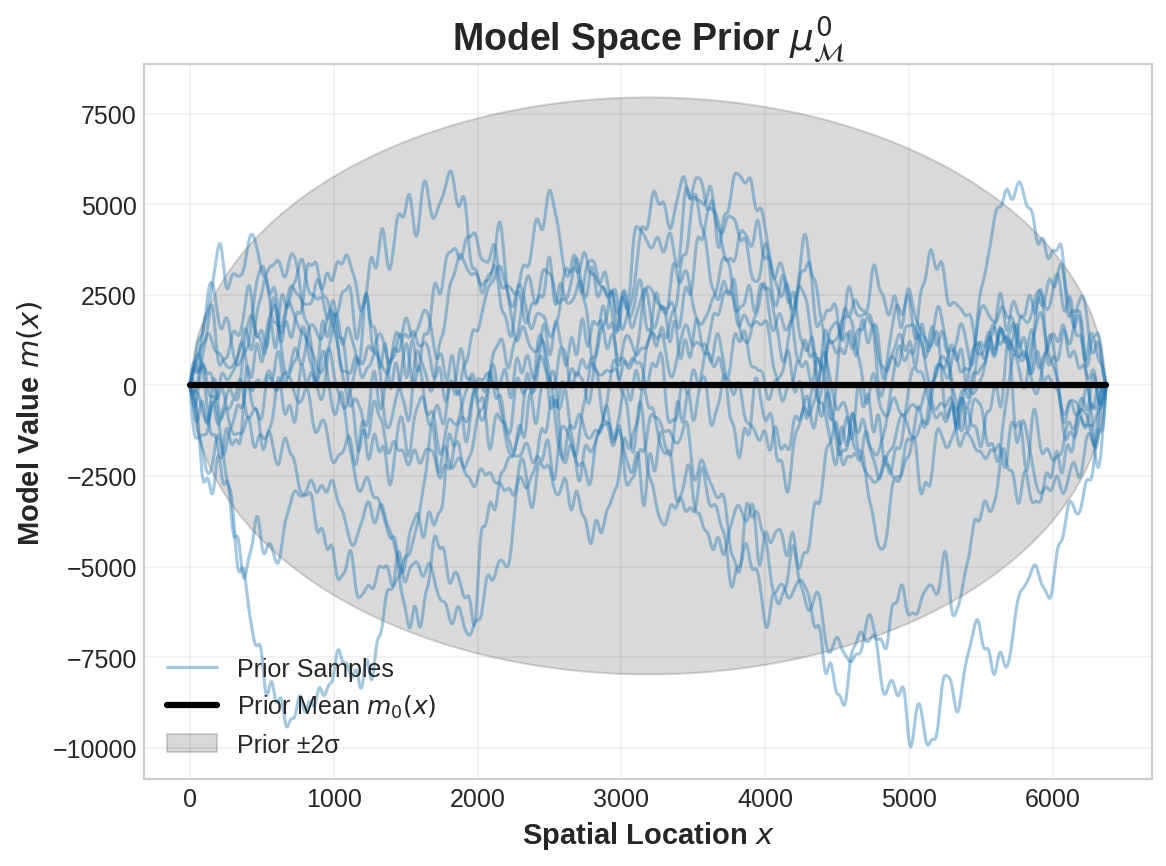

✅ Figure saved: Model space prior samples and mean


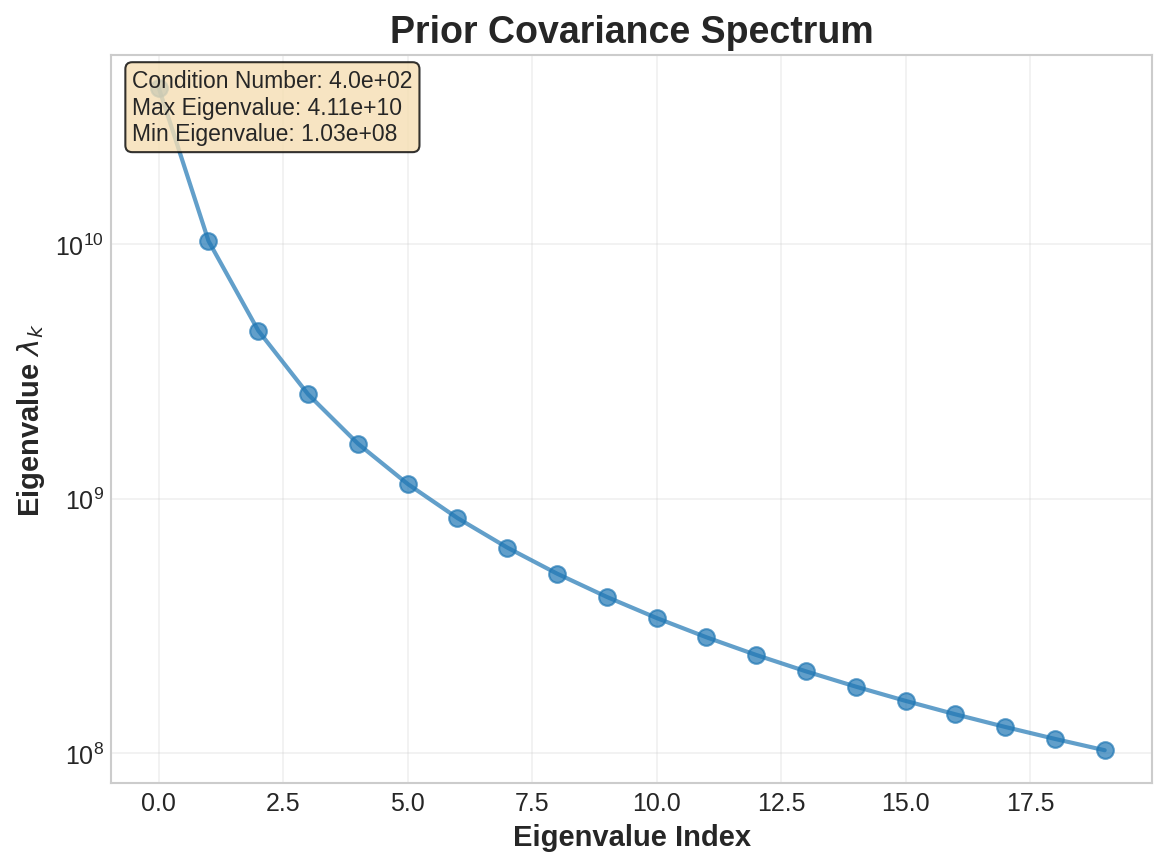

✅ Figure saved: Prior covariance eigenvalue spectrum


In [3]:
x_viz = np.linspace(DOMAIN.a, DOMAIN.b, 1000)
# Left panel: Prior samples and mean (Figure 1)
fig1, ax1 = plt.subplots(figsize=(8, 6))

np.random.seed(RANDOM_SEED)
n_samples = 12
sample_alpha = 0.4

print("🎨 Generating prior samples for visualization...")
for i in range(n_samples):
    sample = kl_sampler.sample()
    ax1.plot(x_viz, sample.evaluate(x_viz), color='tab:blue', alpha=sample_alpha, linewidth=1.5,
             label='Prior Samples' if i == 0 else "")

mean_values = m_0.evaluate(x_viz)
ax1.plot(x_viz, mean_values, 'k-', linewidth=3, label='Prior Mean $m_0(x)$', zorder=10)

print("📊 Computing prior uncertainty bounds...")
std_prior = M.zero
for i in range(min(100, C_0.dofs)):
    eigenval = C_0.get_eigenvalue(i)
    eigenfunction = C_0.get_eigenfunction(i)
    std_prior += eigenval * eigenfunction * eigenfunction
std_values = np.sqrt(std_prior.evaluate(x_viz))

ax1.fill_between(x_viz, mean_values - 2*std_values, mean_values + 2*std_values,
                 alpha=0.15, color='black', label='Prior ±2σ')

ax1.set_xlabel('Spatial Location $x$', fontweight='bold')
ax1.set_ylabel('Model Value $m(x)$', fontweight='bold')
ax1.set_title('Model Space Prior $\\mu_{\\mathcal{M}}^0$', fontweight='bold', fontsize=18)
ax1.legend(loc='lower left')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(presentation_dir, 'slide1_model_prior_samples.png'))
plt.savefig(os.path.join(presentation_dir, 'slide1_model_prior_samples.pdf'))
plt.show()

print("✅ Figure saved: Model space prior samples and mean")

# Right panel: Eigenvalue spectrum (Figure 2)
fig2, ax2 = plt.subplots(figsize=(8, 6))

ax2.semilogy(eigenvals, 'bo-', markersize=8, linewidth=2, alpha=0.7, color='tab:blue')
ax2.set_xlabel('Eigenvalue Index', fontweight='bold')
ax2.set_ylabel('Eigenvalue $\\lambda_k$', fontweight='bold')
ax2.set_title('Prior Covariance Spectrum', fontweight='bold', fontsize=18)
ax2.grid(True, alpha=0.3)

textstr = f"Condition Number: {eigenvals[0]/eigenvals[-1]:.1e}\n" \
           f"Max Eigenvalue: {eigenvals[0]:.2e}\n" \
           f"Min Eigenvalue: {eigenvals[-1]:.2e}"

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax2.text(0.02, 0.98, textstr, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig(os.path.join(presentation_dir, 'slide1_model_prior_spectrum.png'))
plt.savefig(os.path.join(presentation_dir, 'slide1_model_prior_spectrum.pdf'))
plt.show()

print("✅ Figure saved: Prior covariance eigenvalue spectrum")

## Slide 2: Data Space Setup

### Data Space $\mathcal{D}$ and Observations

We define:
- **Data space**: $\mathcal{D} \cong \mathbb{R}^{N_d}$ (finite-dimensional)
- **Data measure**: $\mu_{\mathcal{D}} = \mathcal{N}(\tilde{\mathbf{d}}, \mathbf{C}_{\mathcal{D}})$
- **Observations**: Noisy measurements $\tilde{\mathbf{d}} = G(\bar{m}) + \bm{\eta}$
- **Noise model**: $\bm{\eta} \sim \mathcal{N}(0, \mathbf{C}_{\mathcal{D}})$

In [4]:
# Data space setup
N_DATA = 142
D = EuclideanSpace(N_DATA)

print(f"📊 Data space: ℝ^{N_DATA}")

USE_RANDOM_TRUTH = True
# Create true model for synthetic data generation
if not USE_RANDOM_TRUTH:
    def true_model_function(x):
        """Complex true model with multiple features"""
        # Gaussian envelope
        envelope = np.exp(-(((x / DOMAIN.length) - 0.6)/0.3)**2)
        # Oscillatory component
        oscillation = np.sin(4 * np.pi * (x / DOMAIN.length))
        # Linear trend
        trend = 0.4 * (x / DOMAIN.length)
        # Localized feature
        feature = 0.8 * np.exp(-((x / DOMAIN.length - 0.8)/0.08)**2)
        return envelope * oscillation + trend + feature

    m_true = Function(M, evaluate_callable=true_model_function)
else:
    m_true = kl_sampler.sample()

print("🎯 True model created with multiple challenging features")

📊 Data space: ℝ^142
🎯 True model created with multiple challenging features


### Slide 3: Forward Operator and Sensitivity Kernels

The forward operator $G: \mathcal{M} \to \mathcal{D}$ maps models to data:
$$[G(m)]_i = \langle K_i, m \rangle_{\mathcal{M}}$$

where $K_i$ are sensitivity kernels determining measurement sensitivity.

**Note:** There was a SciPy compatibility issue with `trapz` (deprecated in SciPy 1.14+). This has been fixed in `interval_domain.py` by updating the import to use `trapezoid` instead of `trapz`.

**If you encounter import errors below, please restart the kernel and re-run all cells from the beginning.**

In [5]:
# Create forward operator with normal modes (representing physical measurements)
normal_modes_provider = KernelProvider(M, kernel_type='vs', kernel_data_dir='../kernels_modeplotaat_Adrian')

G = SOLAOperator(M, D, kernels=normal_modes_provider,
                 integration_config=IntegrationConfig(method='trapz', n_points=1000))

print(f"🔄 Forward operator G: ℳ → ℝ^{N_DATA}")
print(f"📡 Sensitivity kernels: Normal modes with Gaussian envelopes")

# Generate synthetic observations
np.random.seed(RANDOM_SEED)
d_clean = G(m_true)
noise_level = 0.01  # 5% noise level
noise_std = noise_level * np.max(np.abs(d_clean))
noise = np.random.normal(0, noise_std, d_clean.shape)
d_tilde = d_clean + noise

# Create data measure
assumed_std = noise_std * 5
noise_variance = assumed_std**2
C_D_matrix = noise_variance * np.eye(N_DATA)
gaussian_D = GaussianMeasure.from_covariance_matrix(D, C_D_matrix, expectation=d_tilde)
gaussian_D_error = GaussianMeasure.from_covariance_matrix(D, C_D_matrix)

print(f"📈 Signal-to-noise ratio: {np.max(np.abs(d_clean))/noise_std:.1f}")
print(f"🔊 Noise level: {noise_level*100}% of signal amplitude")

🔄 Forward operator G: ℳ → ℝ^142
📡 Sensitivity kernels: Normal modes with Gaussian envelopes
📈 Signal-to-noise ratio: 100.0
🔊 Noise level: 1.0% of signal amplitude


🎬 Generating animation frames for PowerPoint...


INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


   ✓ Frame 1 saved


INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral


   ✓ Frame 2 saved


...

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral


   ✓ Frame 4 saved


INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral


   ✓ Frame 5 saved
📊 Creating final complete figure...


INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral


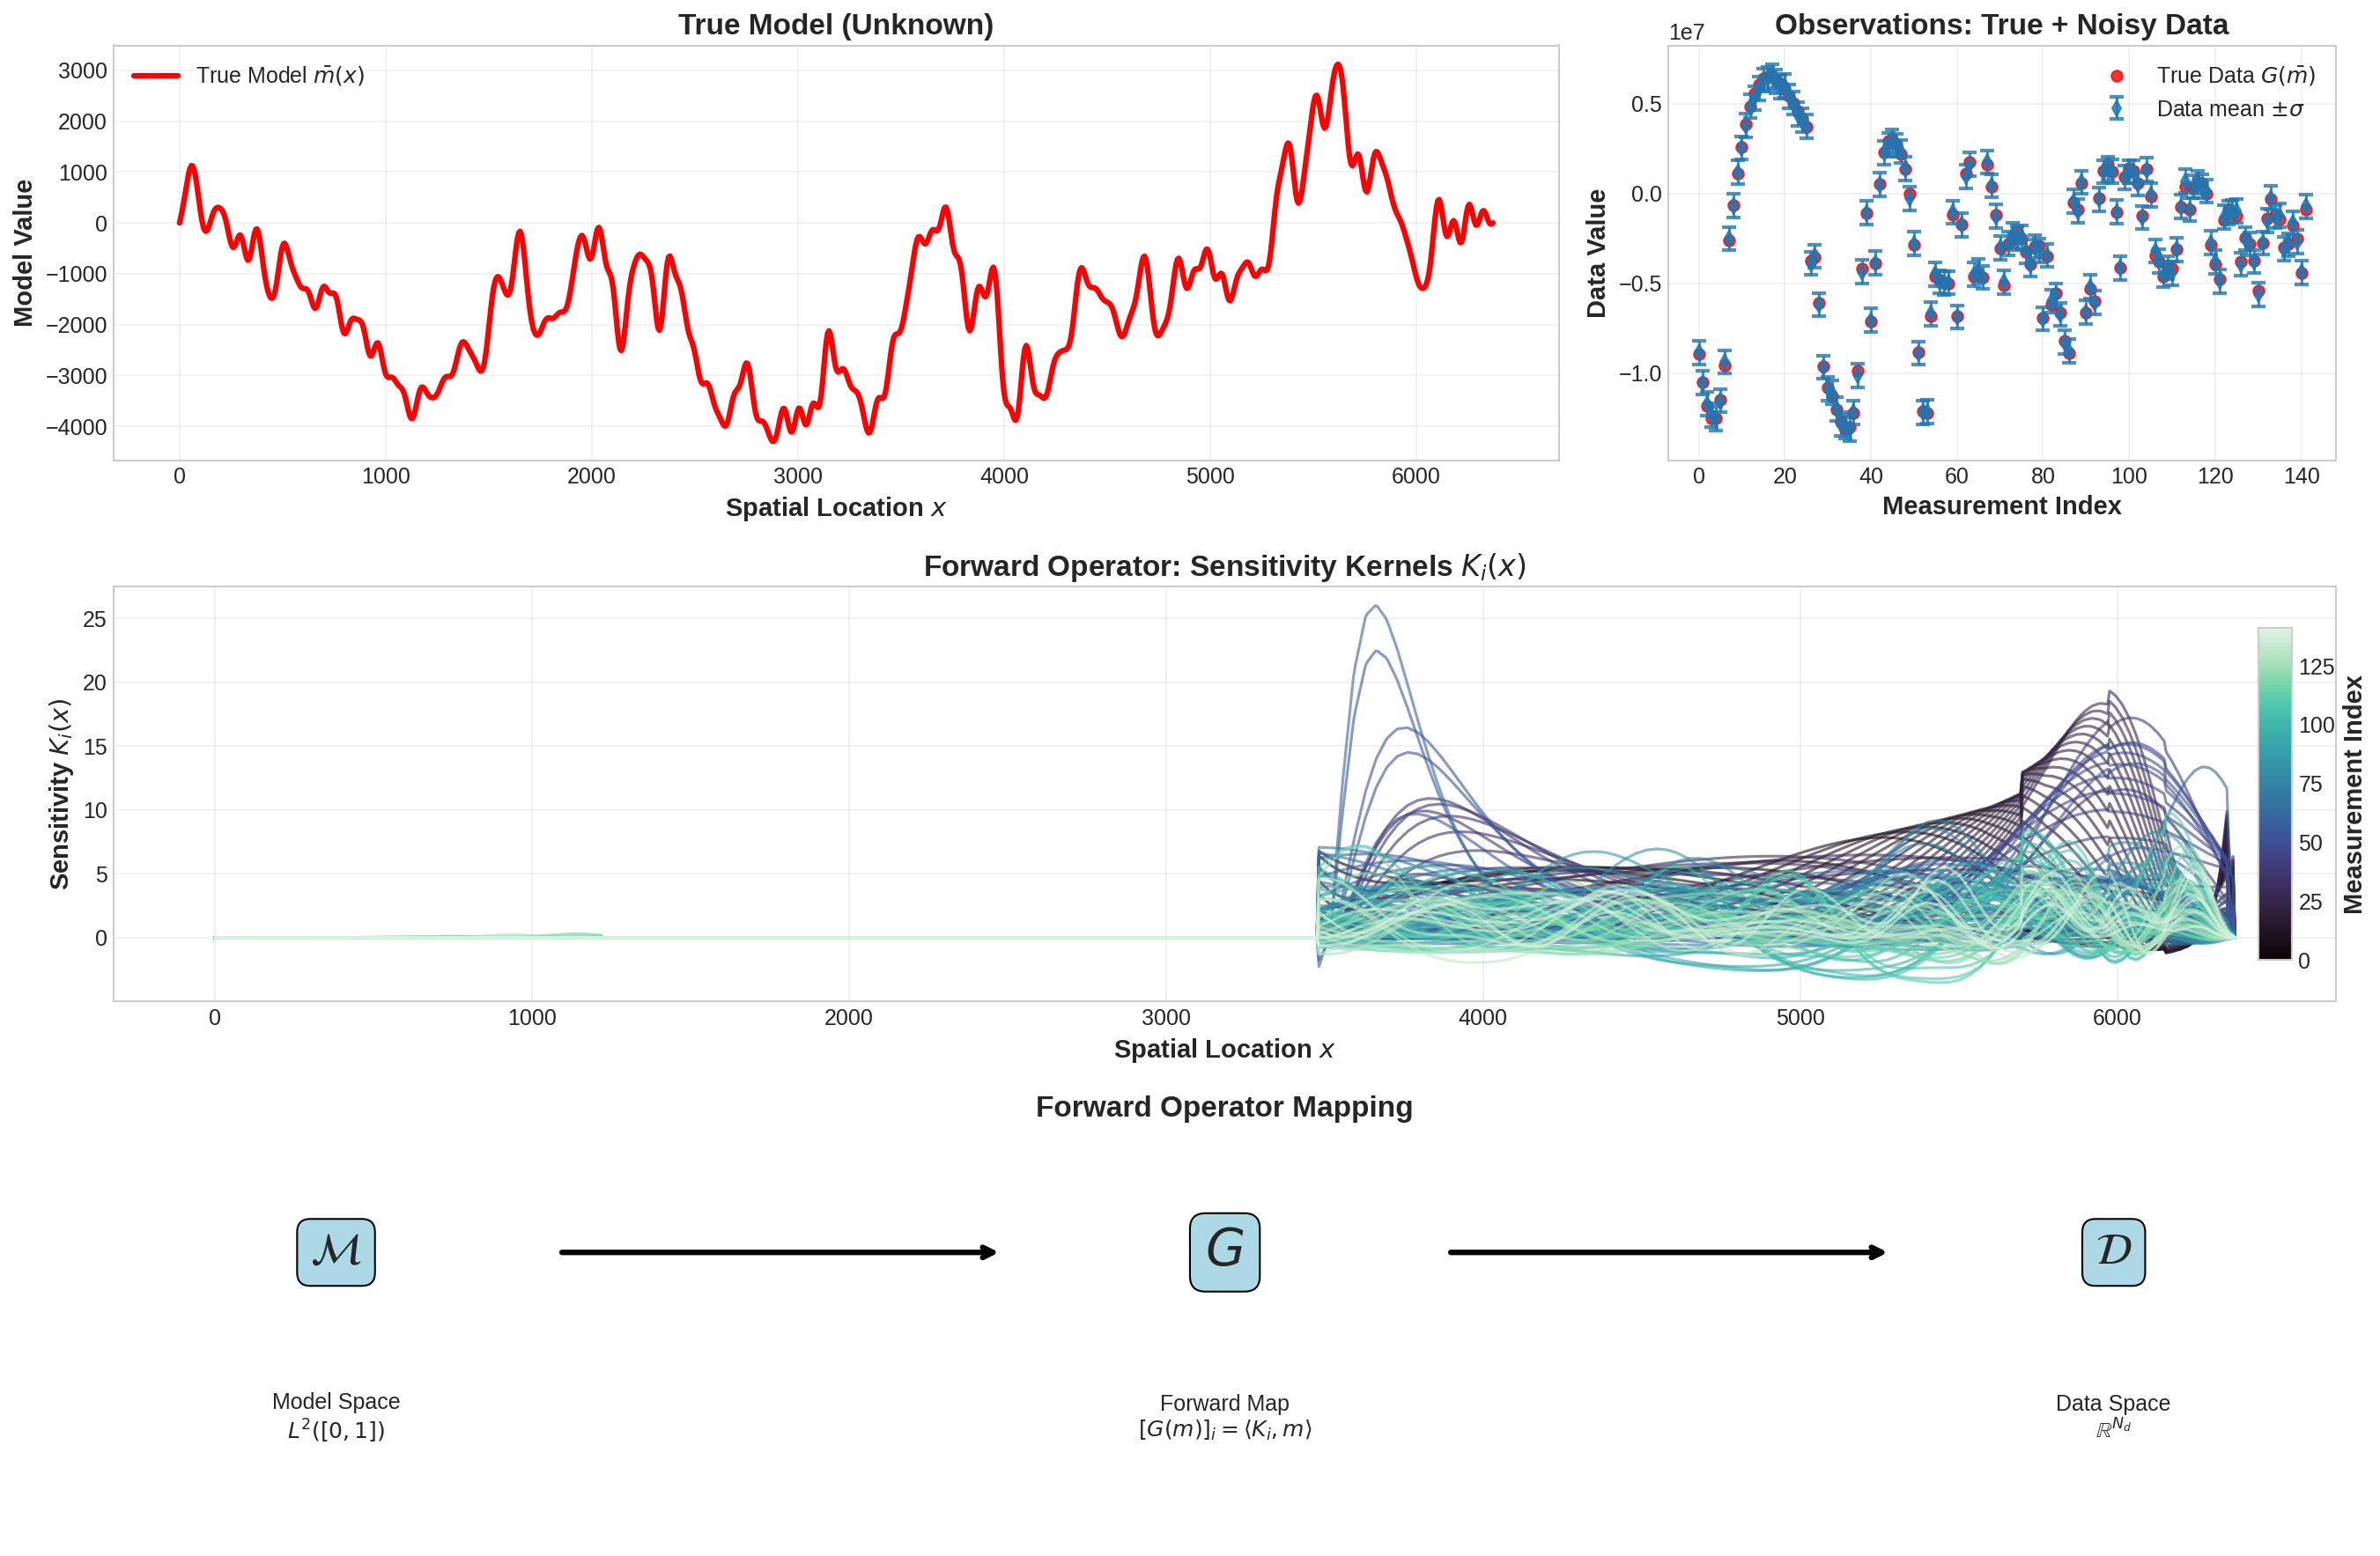

In [6]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Animation toggle control
ENABLE_ANIMATION = True  # Set to False to show only final figure

def create_forward_operator_frame(frame_number, save_prefix="slide2_forward_operator"):
    """
    Create progressive animation frames for PowerPoint presentation.
    All frames have identical size and layout structure for easy alignment.

    Frame 1: True model only
    Frame 2: True model + sensitivity kernels + forward operator schematic
    Frame 3: True model + sensitivity kernels + schematic + true data only
    Frame 4: True model + sensitivity kernels + schematic + true data + noisy measurements
    Frame 5: Complete figure with all elements
    """

    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1], width_ratios=[1, 1, 1])

    # ALWAYS create all subplots for consistent sizing
    ax1 = fig.add_subplot(gs[0, :2])  # Model subplot
    ax2 = fig.add_subplot(gs[0, 2])   # Data subplot
    ax3 = fig.add_subplot(gs[1, :])   # Sensitivity kernels subplot
    ax4 = fig.add_subplot(gs[2, :])   # Forward operator schematic

    # Frame 1+: True model (always present)
    ax1.plot(x_viz, m_true.evaluate(x_viz), 'r-', linewidth=3, label='True Model $\\bar{m}(x)$')
    ax1.set_xlabel('Spatial Location $x$', fontweight='bold')
    ax1.set_ylabel('Model Value', fontweight='bold')
    ax1.set_title('True Model (Unknown)', fontweight='bold', fontsize=16)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Data subplot - configure but may be empty initially
    data_indices = np.arange(N_DATA)
    if frame_number >= 3:
        ax2.set_xlabel('Measurement Index', fontweight='bold')
        ax2.set_ylabel('Data Value', fontweight='bold')
        ax2.set_title('Observations', fontweight='bold', fontsize=16)
        ax2.grid(True, alpha=0.3)
    else:
        ax2.set_xticks([])
        ax2.set_yticks([])
        ax2.set_title('')
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.spines['bottom'].set_visible(False)
        ax2.spines['left'].set_visible(False)

    # Sensitivity kernels subplot
    if frame_number >= 2:
        colors = sns.color_palette("mako", N_DATA)
        for i in range(N_DATA):
            kernel_vals = G.get_kernel(i).evaluate(x_viz)   # updated: was G.function_provider.get_function_by_index(i)
            ax3.plot(x_viz, kernel_vals, color=colors[i], alpha=0.6, linewidth=1.5)

        ax3.set_xlabel('Spatial Location $x$', fontweight='bold')
        ax3.set_ylabel('Sensitivity $K_i(x)$', fontweight='bold')
        ax3.set_title('Forward Operator: Sensitivity Kernels $K_i(x)$', fontweight='bold', fontsize=16)
        ax3.grid(True, alpha=0.3)

        cax = inset_axes(ax3, width="1.5%", height="80%", loc='center right', borderpad=2)
        sm = plt.cm.ScalarMappable(cmap='mako', norm=plt.Normalize(vmin=0, vmax=N_DATA-1))
        sm.set_array([])
        cbar = plt.colorbar(sm, cax=cax)
        cbar.set_label('Measurement Index', fontweight='bold')
    else:
        ax3.set_xticks([])
        ax3.set_yticks([])
        ax3.set_title('')
        ax3.spines['top'].set_visible(False)
        ax3.spines['right'].set_visible(False)
        ax3.spines['bottom'].set_visible(False)
        ax3.spines['left'].set_visible(False)

    # Forward operator schematic
    if frame_number >= 2:
        ax4.text(0.1, 0.7, '$\\mathcal{M}$', fontsize=24, ha='center', va='center',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
        ax4.text(0.5, 0.7, '$G$', fontsize=28, ha='center', va='center',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
        ax4.text(0.9, 0.7, '$\\mathcal{D}$', fontsize=24, ha='center', va='center',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))

        ax4.annotate('', xy=(0.4, 0.7), xytext=(0.2, 0.7),
                     arrowprops=dict(arrowstyle='->', lw=3, color='black'))
        ax4.annotate('', xy=(0.8, 0.7), xytext=(0.6, 0.7),
                     arrowprops=dict(arrowstyle='->', lw=3, color='black'))

        ax4.text(0.1, 0.3, 'Model Space\n$L^2([0,1])$', fontsize=12, ha='center', va='center')
        ax4.text(0.5, 0.3, 'Forward Map\n$[G(m)]_i = \\langle K_i, m \\rangle$', fontsize=12, ha='center', va='center')
        ax4.text(0.9, 0.3, 'Data Space\n$\\mathbb{R}^{N_d}$', fontsize=12, ha='center', va='center')

        ax4.set_title('Forward Operator Mapping', fontweight='bold', fontsize=16)

    ax4.set_xlim(0, 1)
    ax4.set_ylim(0, 1)
    ax4.axis('off')

    if frame_number >= 3:
        ax2.plot(data_indices, d_clean, 'ro', alpha=0.8, markersize=6, label='True Data $G(\\bar{m})$')
        ax2.set_title('Observations: True Data', fontweight='bold', fontsize=16)
        ax2.legend()

    if frame_number == 4:
        ax2.plot(data_indices, d_tilde, 'bd', alpha=0.8,
                label='Noisy Measurements', markersize=6, color='tab:blue')
        ax2.set_title('Observations: True + Noisy Data', fontweight='bold', fontsize=16)
        ax2.legend()

    if frame_number >= 5:
        ax2.errorbar(data_indices, d_tilde, yerr=assumed_std, fmt='bd', alpha=0.8,
                capsize=4, capthick=2, label='Data mean $\pm \\sigma$', markersize=6, color='tab:blue')
        ax2.set_title('Observations: True + Noisy Data', fontweight='bold', fontsize=16)
        ax2.legend()

    plt.tight_layout()

    frame_filename = f'{save_prefix}_frame{frame_number}.png'
    plt.savefig(os.path.join(presentation_dir, frame_filename), dpi=300, bbox_inches='tight')

    return fig

if ENABLE_ANIMATION:
    print("🎬 Generating animation frames for PowerPoint...")
    for frame in range(1, 6):
        fig = create_forward_operator_frame(frame)
        plt.close(fig)
        print(f"   ✓ Frame {frame} saved")
    print("📊 Creating final complete figure...")
    final_fig = create_forward_operator_frame(5, "slide2_forward_operator_complete")
else:
    print("📊 Animation disabled - creating only final complete figure...")
    final_fig = create_forward_operator_frame(5, "slide2_forward_operator_complete")

plt.show()

## Slide 3: Probabilistic Inversion - Computing the Posterior

### Bayesian Update

Using Bayes' theorem, we compute the model posterior:

$$\mu_{\mathcal{M}}^{\tilde{\mathbf{d}}} = \mathcal{N}(\tilde{m}, C_{\mathcal{M}})$$

where:
- **Posterior covariance**: $C_{\mathcal{M}} = (G^* \mathbf{C}_{\mathcal{D}}^{-1} G + C_0^{-1})^{-1}$
- **Posterior mean**: $\tilde{m} = C_{\mathcal{M}}(G^* \mathbf{C}_{\mathcal{D}}^{-1} \tilde{\mathbf{d}} + C_0^{-1} m_0)$

This represents our updated beliefs about the model after seeing the data.

In [7]:
# Compute Bayesian inversion using PyGeoInf
print("🔄 Computing Bayesian inversion...")

# Build a GaussianMeasure wrapping the prior covariance and KL sampler
model_prior = GaussianMeasure(covariance=C_0, expectation=m_0, sample=kl_sampler.sample)

# Create forward problem
forward_problem = LinearForwardProblem(G, data_error_measure=gaussian_D_error)

# Create Bayesian inversion object
bayesian_inversion = LinearBayesianInversion(forward_problem, model_prior)

# Compute model posterior
solver = LUSolver()
model_posterior = bayesian_inversion.model_posterior_measure(d_tilde, solver)

print(f"✓ Posterior computed successfully")

# Get posterior mean (expectation is already a function)
posterior_mean = model_posterior.expectation

print(f"✓ Bayesian inversion completed")

🔄 Computing Bayesian inversion...
✓ Posterior computed successfully
✓ Bayesian inversion completed


### Inversion Results - Posterior vs. Truth

This slide shows the power and limitations of probabilistic inversion:
- **Success**: Posterior mean recovers true model reasonably well
- **Uncertainty**: Posterior samples show remaining uncertainty
- **Challenge**: How do we extract specific information from this posterior?

🎨 Generating posterior samples for inversion results...


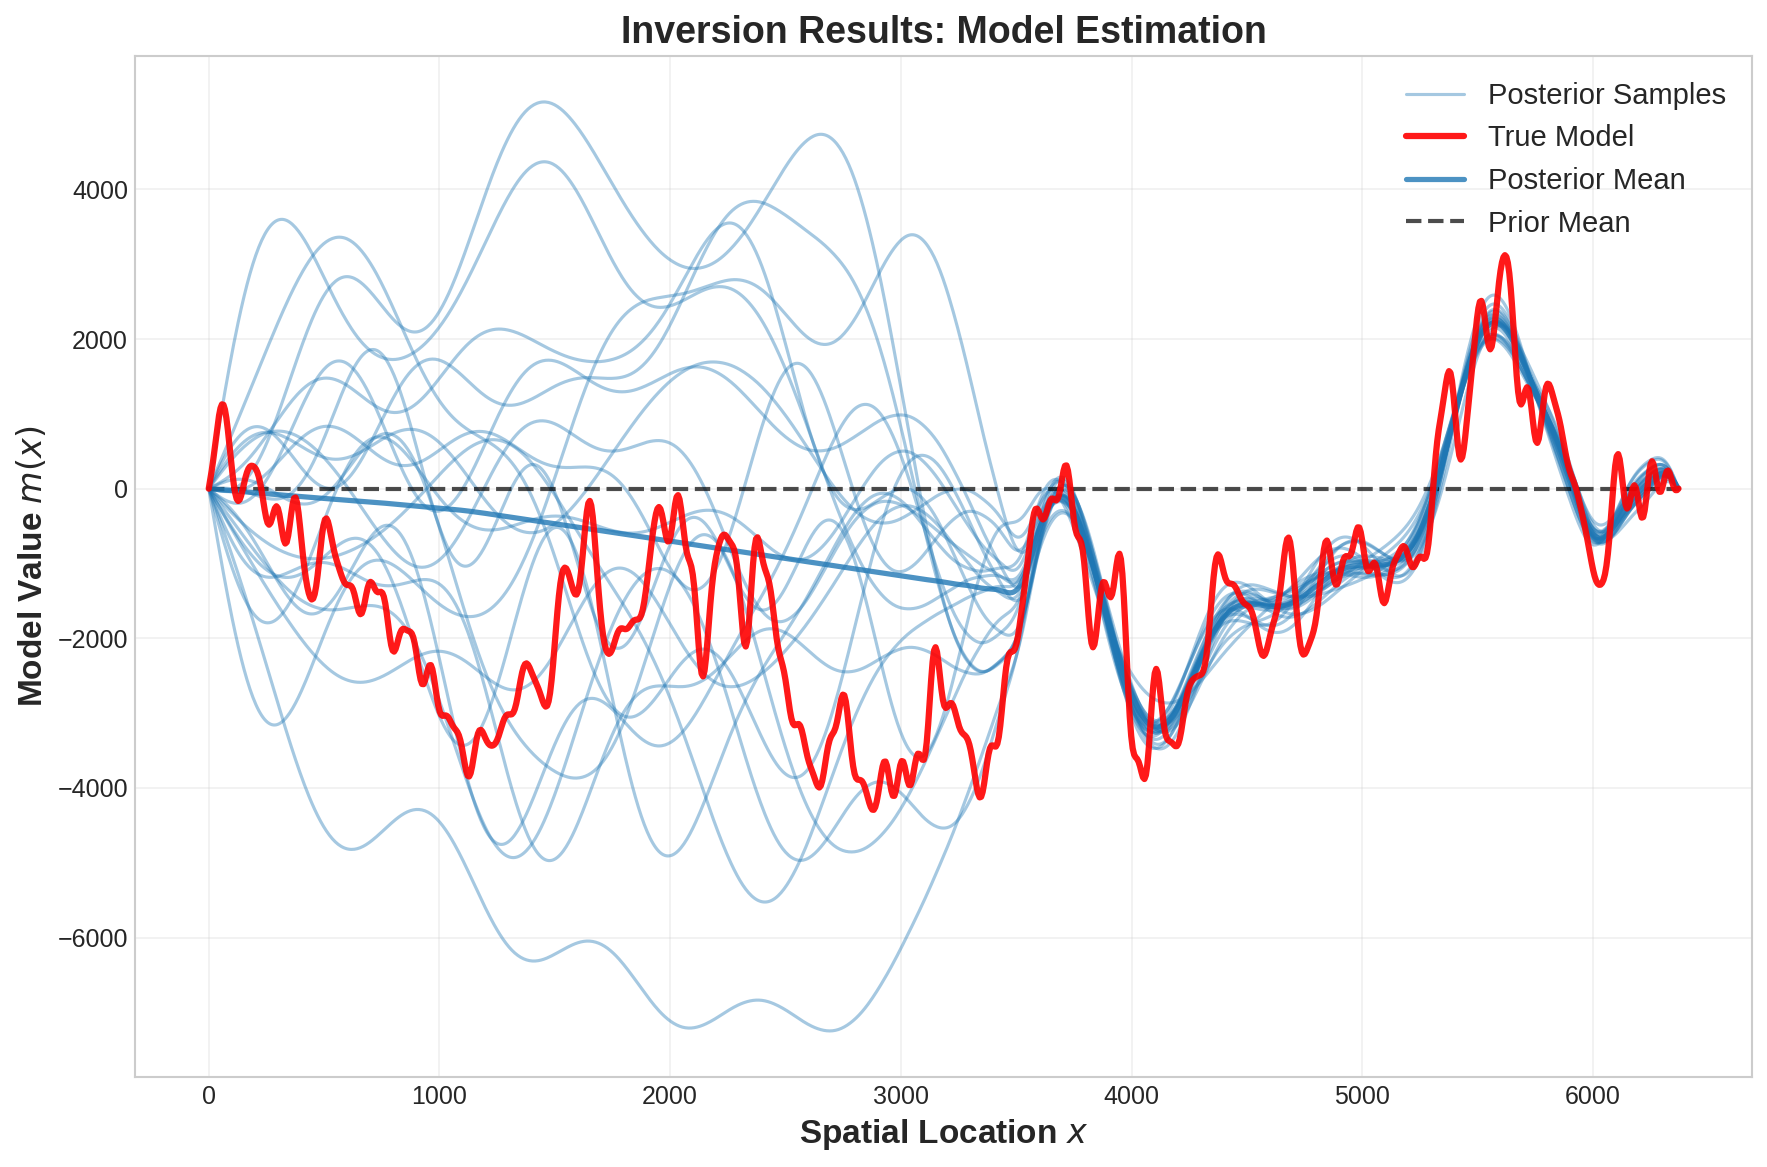

✅ Slide 3 figure saved: Inversion results and analysis


In [8]:
# Create figure for inversion results (Slide 7) - model estimation only
fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')

# Generate posterior samples for visualization using prior samples + update
print("🎨 Generating posterior samples for inversion results...")
np.random.seed(RANDOM_SEED)
n_post_samples = 20
cov_M_posterior = model_posterior.covariance.matrix(dense=True)  # Use dense matrix for better visualization
# Recreatig posterior gaussian measure with dense covariance for sampling
mu_M  = GaussianMeasure.from_covariance_matrix(M, cov_M_posterior, expectation=model_posterior.expectation)

# Generate samples by perturbing the posterior mean
for i in range(n_post_samples):
    sample_values = mu_M.sample().evaluate(x_viz)
    ax.plot(x_viz, sample_values, color='tab:blue', alpha=sample_alpha, linewidth=1.5,
             label='Posterior Samples' if i == 0 else "")

ax.plot(x_viz, m_true.evaluate(x_viz), 'r-', linewidth=3, label='True Model', alpha=0.9, zorder=10)
ax.plot(x_viz, posterior_mean.evaluate(x_viz), color='tab:blue', linewidth=2.5, label='Posterior Mean', alpha=0.8, zorder=9)
ax.plot(x_viz, m_0.evaluate(x_viz), 'k--', linewidth=2, label='Prior Mean', alpha=0.7, zorder=8)

ax.set_xlabel('Spatial Location $x$', fontweight='bold', fontsize=16)
ax.set_ylabel('Model Value $m(x)$', fontweight='bold', fontsize=16)
ax.set_title('Inversion Results: Model Estimation', fontsize=18, fontweight='bold')
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{presentation_dir}/slide3_inversion_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Slide 3 figure saved: Inversion results and analysis")

## Slide 8: The Challenge - Extracting Information from Posterior

### Key Questions That Motivate Linear Inference

Having computed the model posterior $\mu_{\mathcal{M}}^{\tilde{\mathbf{d}}}$, we face important questions:

1. **What is the average value** of the model over a specific region?
2. **How does the model behave** near a particular location?
3. **What is the total integrated quantity** over the domain?
4. **Can we extract gradients** or other derived quantities?

### The Problem

Even with an analytical posterior solution, extracting specific properties is **not trivial**:
- Direct sampling is computationally expensive
- Point-wise evaluation doesn't give integrated quantities
- Derived quantities (gradients, averages) require careful computation
- Uncertainty propagation becomes complex

**Solution**: Linear inference provides a principled framework for extracting properties with proper uncertainty quantification.

🎬 Generating challenge questions animation frames for PowerPoint...
   ✓ Frame 1 saved
   ✓ Frame 2 saved
   ✓ Frame 3 saved
   ✓ Frame 4 saved
📊 Creating final complete challenge questions figure...


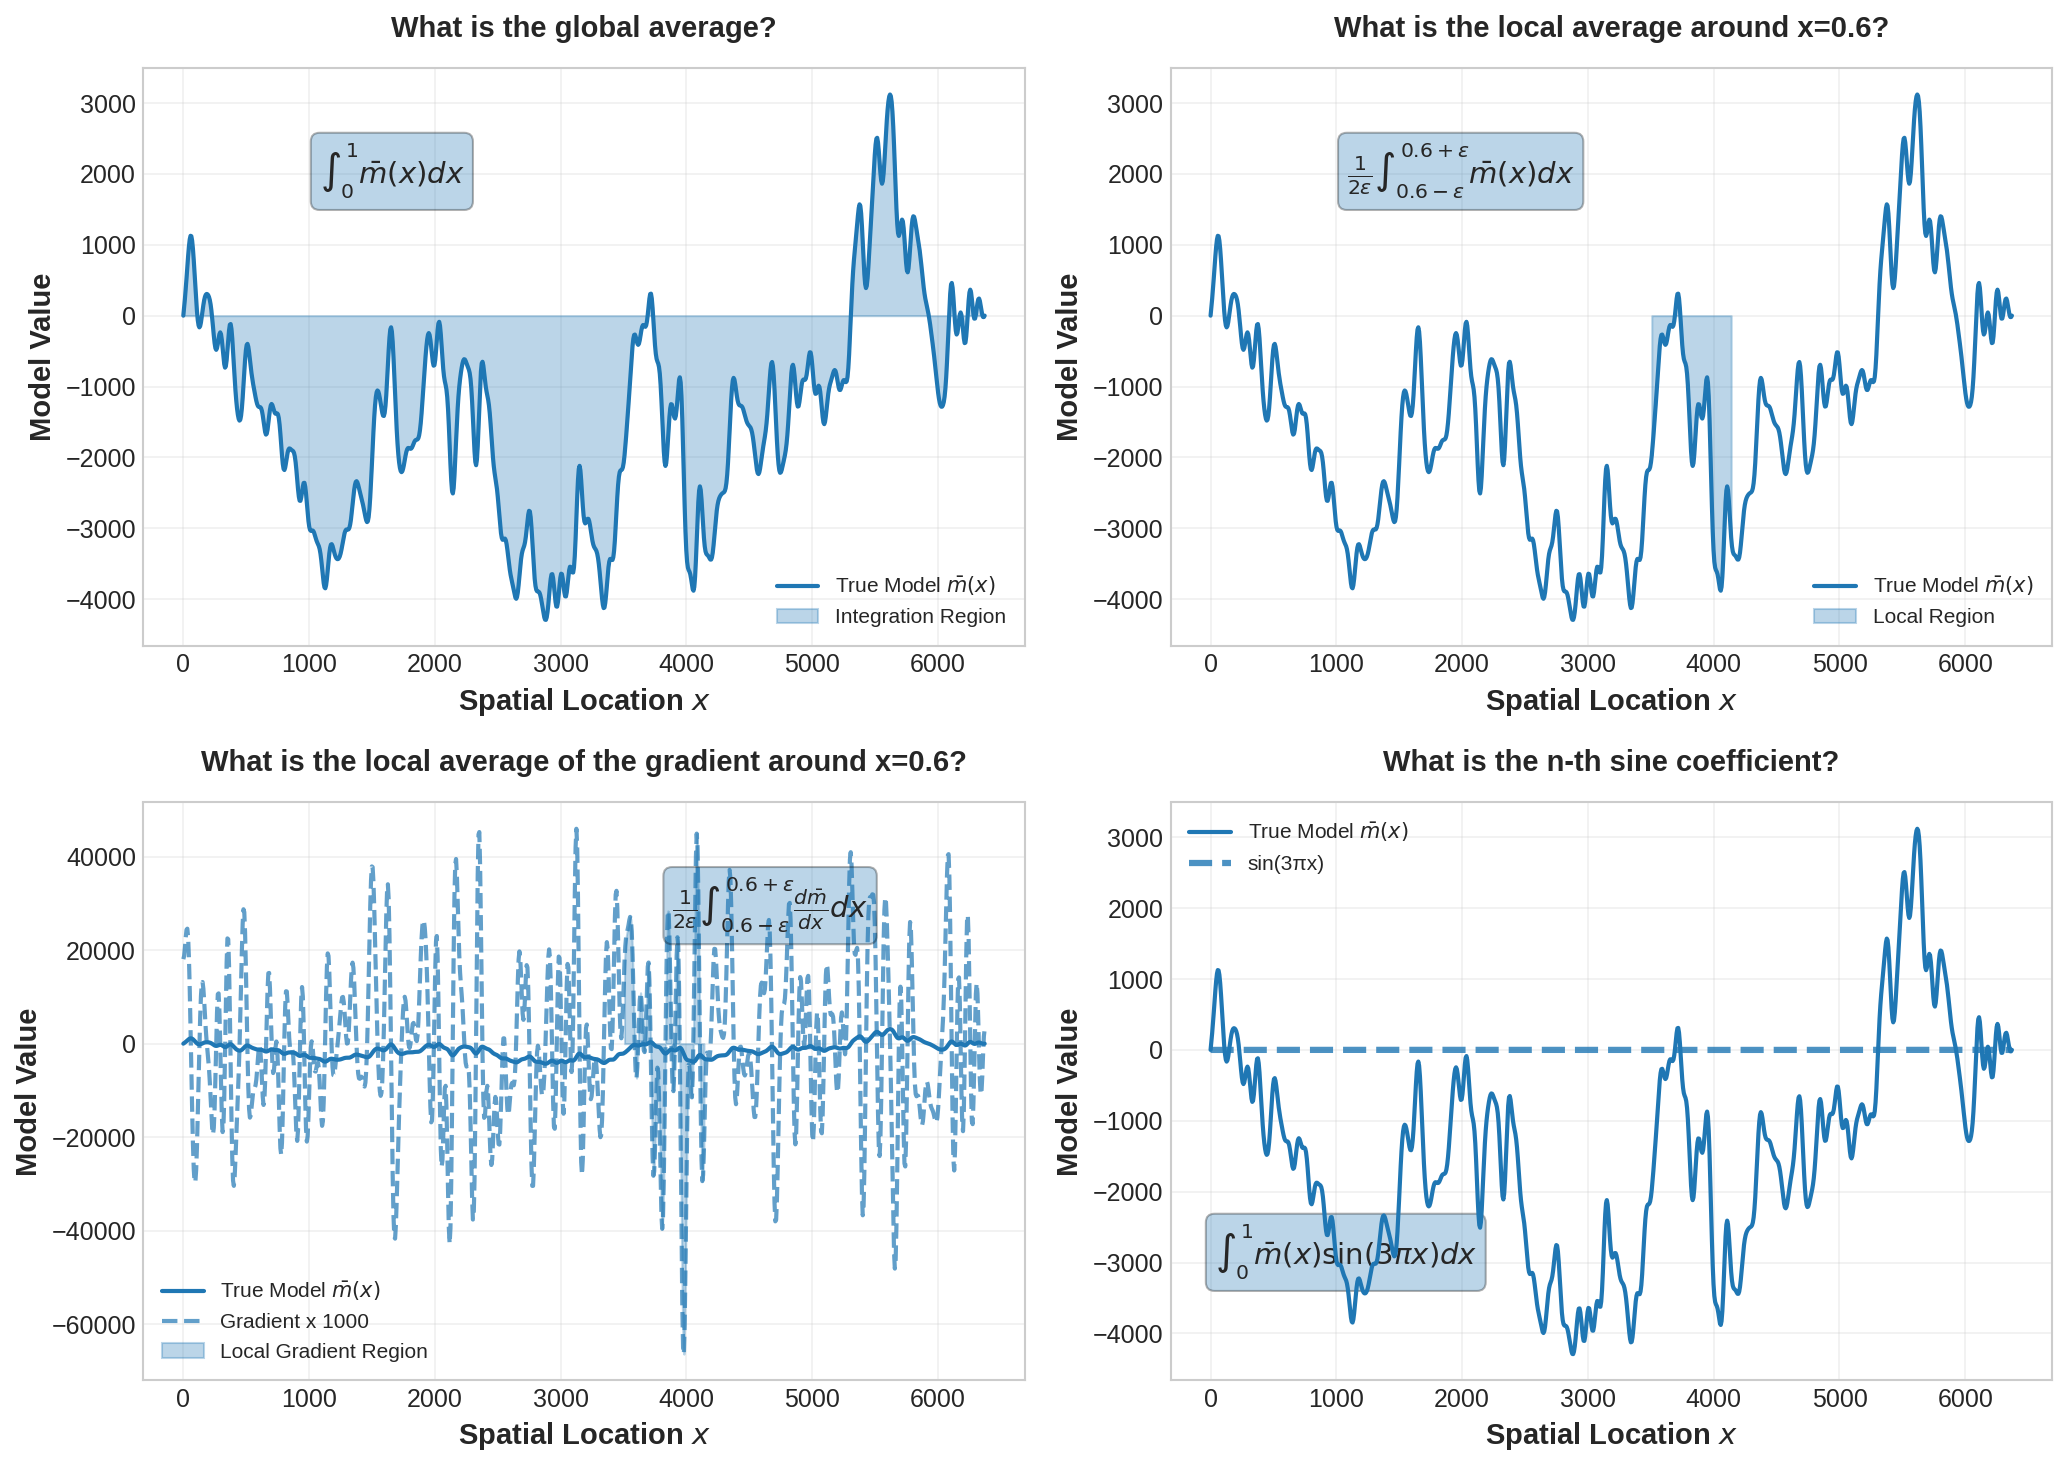

✅ Slide 4 figure saved: Challenge questions motivating linear inference


In [9]:
# Create figure for challenge questions (Slide 8)
def create_challenge_questions_frame(frame_number, save_prefix="slide4_challenge_questions"):
    """
    Create progressive animation frames for challenge questions.
    All frames have identical size and layout structure for easy alignment.

    Frame 1: Global average only
    Frame 2: Global average + Local gradient average
    Frame 3: Global average + Local gradient average + Local average
    Frame 4: All four questions (complete)
    """

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')

    # Questions to motivate linear inference
    questions = [
        "What is the global average?",
        "What is the local average around x=0.6?",
        "What is the local average of the gradient around x=0.6?",
        "What is the n-th sine coefficient?"
    ]

    # Control which subplots to show based on frame number
    active_subplots = []
    if frame_number >= 1:
        active_subplots.append(0)  # Global average
    if frame_number >= 2:
        active_subplots.append(1)  # Local average
    if frame_number >= 3:
        active_subplots.append(2)  # Local gradient average
    if frame_number >= 4:
        active_subplots.append(3)  # n-th sine coefficient

    # Process each subplot
    for idx, (ax, question) in enumerate(zip(axes.flat, questions)):
        if idx in active_subplots:
            # Plot True Model
            ax.plot(x_viz, m_true.evaluate(x_viz), color='tab:blue', linewidth=2,
                   label='True Model $\\bar{m}(x)$', zorder=10)

            # Highlight different regions/aspects for each question
            if idx == 0:  # Global average
                ax.fill_between(x_viz, m_true.evaluate(x_viz), alpha=0.3, color='tab:blue',
                               label='Integration Region')
                ax.text(0.2, 0.8, r'$\int_0^1 \bar{m}(x) dx$', fontsize=14, transform=ax.transAxes,
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="tab:blue", alpha=0.3))

            elif idx == 1:  # Local average around x=0.6
                x_center = 0.6 * DOMAIN.length
                width = 0.1 * DOMAIN.length
                mask = (x_viz >= x_center - width/2) & (x_viz <= x_center + width/2)
                ax.fill_between(x_viz[mask], m_true.evaluate(x_viz)[mask], alpha=0.3,
                               color='tab:blue', label=f'Local Region')
                ax.text(0.2, 0.8, r'$\frac{1}{2\epsilon}\int_{0.6-\epsilon}^{0.6+\epsilon} \bar{m}(x) dx$',
                        fontsize=14, transform=ax.transAxes,
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="tab:blue", alpha=0.3))

            elif idx == 2:  # Local average of gradient
                x_center = 0.6 * DOMAIN.length
                width = 0.1 * DOMAIN.length
                # Compute and plot gradient
                dm_dx = 1000*np.gradient(m_true.evaluate(x_viz), x_viz)
                ax.plot(x_viz, dm_dx, '--', color='tab:blue', linewidth=2, alpha=0.7, label='Gradient x 1000')
                # Highlight local region
                mask = (x_viz >= x_center - width/2) & (x_viz <= x_center + width/2)
                ax.fill_between(x_viz[mask], dm_dx[mask], alpha=0.3,
                               color='tab:blue', label=f'Local Gradient Region')
                ax.text(0.6, 0.8, r"$\frac{1}{2\epsilon}\int_{0.6-\epsilon}^{0.6+\epsilon} \frac{d \bar{m}}{dx} dx$",
                        fontsize=14, transform=ax.transAxes,
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="tab:blue", alpha=0.3))

            elif idx == 3:  # n-th Fourier coefficient
                # Show the basis function for n-th Fourier mode
                n_fourier = 3  # Example: 3rd Fourier coefficient
                fourier_mode = np.sin(n_fourier * np.pi * (x_viz / DOMAIN.length))
                ax.plot(x_viz, fourier_mode, '--', linewidth=3, alpha=0.8,
                       label=f'sin({n_fourier}πx)', color='tab:blue')
                ax.text(0.05, 0.2, rf'$\int_0^1 \bar m(x) \sin({n_fourier}\pi x) dx$',
                        fontsize=14, transform=ax.transAxes,
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="tab:blue", alpha=0.3))

            ax.set_title(question, fontsize=14, fontweight='bold', pad=15)
            ax.set_xlabel('Spatial Location $x$', fontweight='bold')
            ax.set_ylabel('Model Value', fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=10)
        else:
            # Hide inactive subplots
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title('')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)

    plt.tight_layout()

    # Save frame
    frame_filename = f'{save_prefix}_frame{frame_number}.png'
    plt.savefig(os.path.join(presentation_dir, frame_filename), dpi=300, bbox_inches='tight')

    return fig

if ENABLE_ANIMATION:
    # Generate all animation frames for challenge questions
    print("🎬 Generating challenge questions animation frames for PowerPoint...")
    for frame in range(1, 5):
        fig = create_challenge_questions_frame(frame)
        plt.close(fig)  # Close each frame to save memory
        print(f"   ✓ Frame {frame} saved")

    # Create and display the final complete figure
    print("📊 Creating final complete challenge questions figure...")
    final_fig = create_challenge_questions_frame(4, "slide4_challenge_questions_complete")
else:
    print("📊 Creating final complete challenge questions figure...")
    final_fig = create_challenge_questions_frame(4, "slide4_challenge_questions_complete")
plt.show()

print("✅ Slide 4 figure saved: Challenge questions motivating linear inference")

# Part 2: Linear Inference Framework

## The Solution: Property-Focused Inference

Instead of computing the full model posterior and then extracting properties, we directly target the **properties of interest**.

### Linear Inference Paradigm

**Key insight**: If we only care about linear functionals of the model, we can:
1. Define a **property space** $\mathcal{P}$ 
2. Create **target operators** $T: \mathcal{M} \to \mathcal{P}$ that extract properties
3. Compute **property posterior** $\mu_{\mathcal{P}}^{\tilde{\mathbf{d}}}$ directly

### Mathematical Framework

- **Target operator**: $T: \mathcal{M} \to \mathcal{P}$ (linear functional)
- **Property posterior**: $\mu_{\mathcal{P}}^{\tilde{\mathbf{d}}} = T_{\#}\mu_{\mathcal{M}}^{\tilde{\mathbf{d}}}$ (push-forward measure)
- **Gaussian structure**: If $\mu_{\mathcal{M}}^{\tilde{\mathbf{d}}}$ is Gaussian, then $\mu_{\mathcal{P}}^{\tilde{\mathbf{d}}}$ is also Gaussian

---

## Slide 5: Property Space and Target Operators

🎯 Setting up Linear Inference Framework...
📐 Property space: ℝ^1 (single local average)
✓ Target operator: Local uniform average around x=5096.8
✓ Integration region: [4459.7, 5733.9]
✓ Kernel normalization: ∫ T(x) dx = 1.000


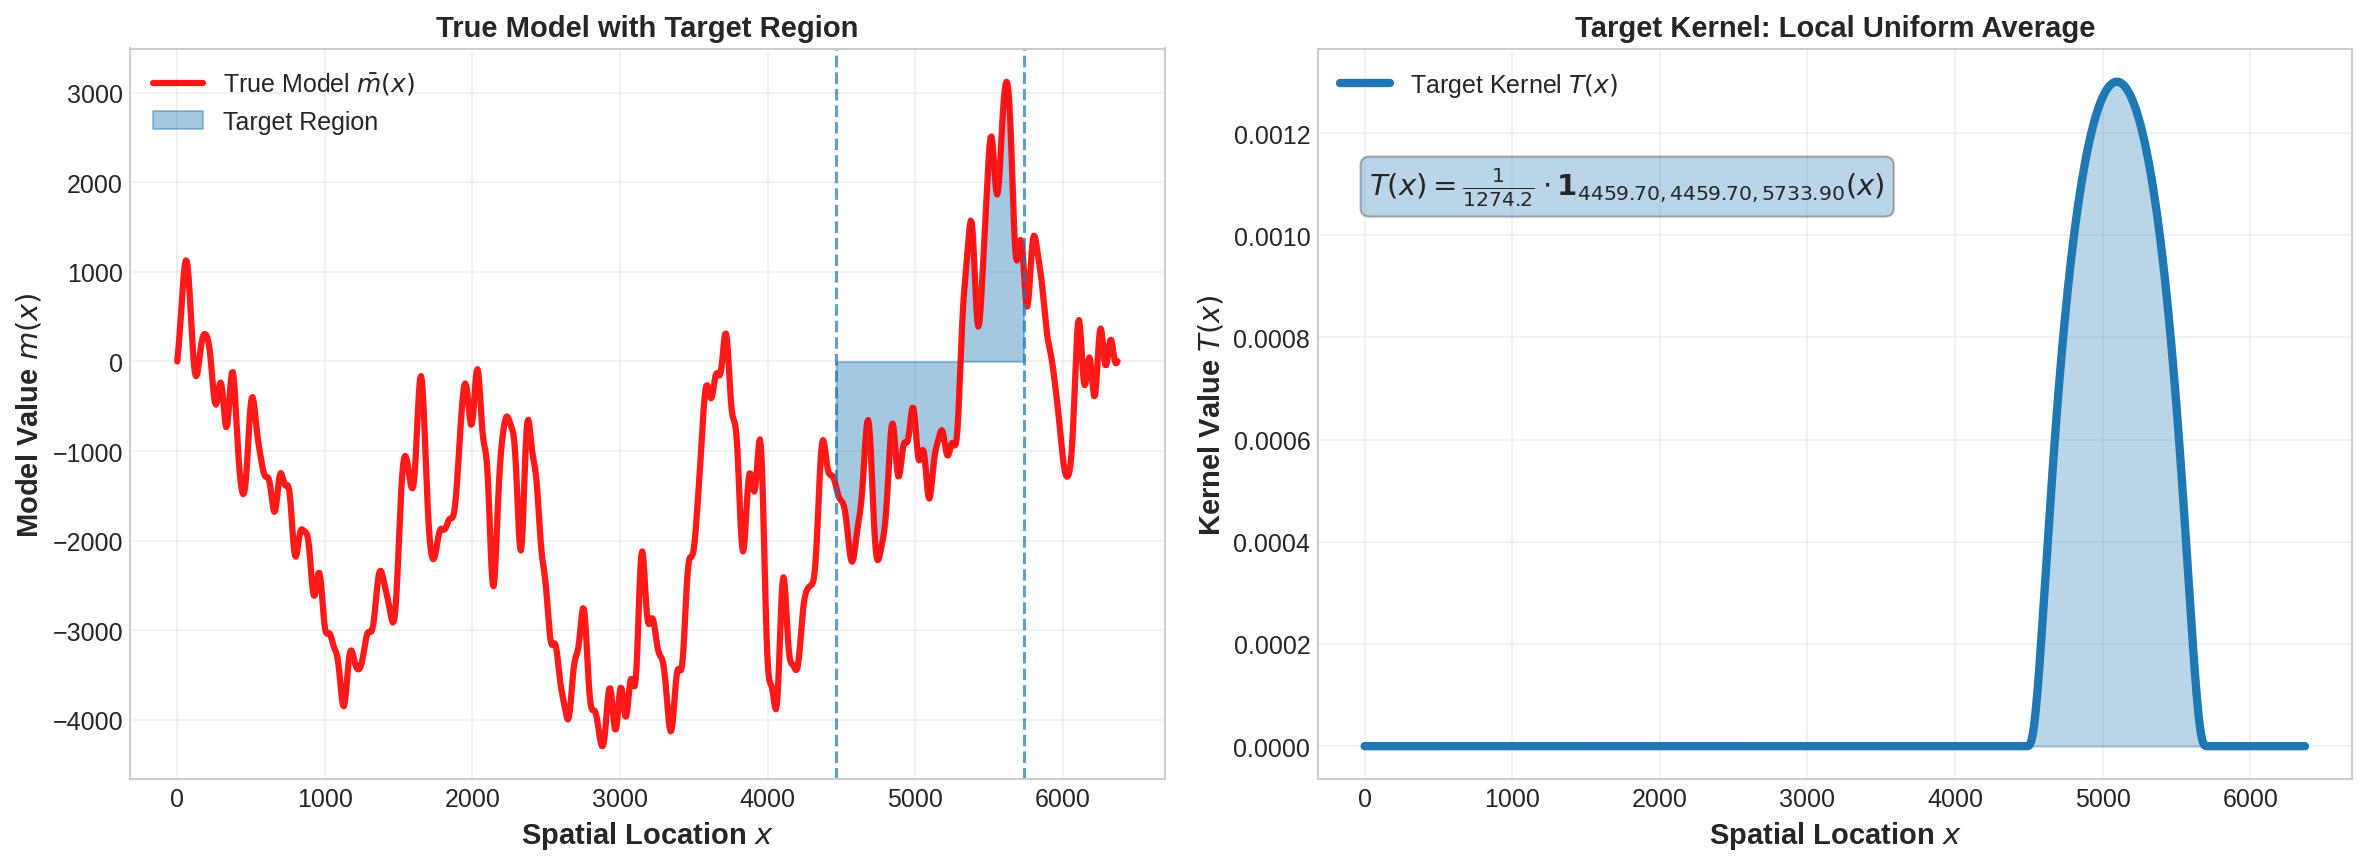

✅ Slide 5 figure saved: Target operator definition


In [10]:
# Define Property Space and Target Operator
print("🎯 Setting up Linear Inference Framework...")

# Property space (for now, 1D for local average)
N_PROPERTIES = 1  # Single property for local average
P = EuclideanSpace(N_PROPERTIES)
print(f"📐 Property space: ℝ^{P.dim} (single local average)")

# Target function parameters
width = 0.2 * DOMAIN.length  # Width of local average
centers = np.array([0.8 * DOMAIN.length])  # Center of local average

# Create target operator using proper function provider
target_kernel_provider = BumpFunctionProvider(M, centers=centers, default_width=width)

print(f"✓ Target operator: Local uniform average around x={centers[0]}")
print(f"✓ Integration region: [{centers[0] - width/2:.1f}, {centers[0] + width/2:.1f}]")
print(f"✓ Kernel normalization: ∫ T(x) dx = {target_kernel_provider.get_function_by_index(0).integrate():.3f}")

# Visualize the target kerneltab:blue
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

# Left panel: True model with target region
ax = axes[0]
ax.plot(x_viz, m_true.evaluate(x_viz), 'r-', linewidth=3, label='True Model $\\bar{m}(x)$', alpha=0.9)
ax.fill_between(x_viz, m_true.evaluate(x_viz),
                where=((x_viz >= centers[0] - width/2) & (x_viz <= centers[0] + width/2)),
                alpha=0.4, color='tab:blue', label='Target Region')
ax.axvline(centers[0] - width/2, color='tab:blue', linestyle='--', alpha=0.7)
ax.axvline(centers[0] + width/2, color='tab:blue', linestyle='--', alpha=0.7)

ax.set_xlabel('Spatial Location $x$', fontweight='bold')
ax.set_ylabel('Model Value $m(x)$', fontweight='bold')
ax.set_title('True Model with Target Region', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Right panel: Target kernel
ax = axes[1]
ax.plot(x_viz, target_kernel_provider.get_function_by_index(0).evaluate(x_viz), 'tab:blue', linewidth=4, label='Target Kernel $T(x)$')
ax.fill_between(x_viz, target_kernel_provider.get_function_by_index(0).evaluate(x_viz), alpha=0.3, color='tab:blue')

ax.set_xlabel('Spatial Location $x$', fontweight='bold')
ax.set_ylabel('Kernel Value $T(x)$', fontweight='bold')
ax.set_title('Target Kernel: Local Uniform Average', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Add mathematical description
ax.text(0.05, 0.8, f'$T(x) = \\frac{{1}}{{{width}}} \\cdot \\mathbf{{1}}_{{{centers[0] - width/2:.2f}, {centers[0] - width/2:.2f}, {centers[0] + width/2:.2f}}}(x)$',
        fontsize=14, transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="tab:blue", alpha=0.3))

plt.tight_layout()
plt.savefig(f'{presentation_dir}/slide5_target_operator.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Slide 5 figure saved: Target operator definition")

## Slide 6: Computing Linear Inference

### The Linear Inference Formula

For a linear target operator $T: \mathcal{M} \to \mathcal{P}$, the property posterior is:

$$\mu_{\mathcal{P}}^{\tilde{\mathbf{d}}} = \mathcal{N}(\hat{p}, \sigma_p^2)$$

where:
- **Property mean**: $\hat{p} = T(\tilde{m})$ 
- **Property variance**: $\sigma_p^2 = T(C_{\mathcal{M}} T^*)$

### Key Advantages

1. **Direct computation**: No need to sample from model posterior
2. **Exact uncertainty**: Analytical variance computation
3. **Computational efficiency**: Avoid high-dimensional sampling
4. **Property-focused**: Get exactly what you need

### Implementation Steps

1. Compute model posterior $\mu_{\mathcal{M}}^{\tilde{\mathbf{d}}}$ (as before)
2. Apply target operator to posterior mean: $\hat{p} = T(\tilde{m})$
3. Compute property uncertainty: $\sigma_p^2 = T(C_{\mathcal{M}} T^*)$

In [11]:
# Compute Linear Inference using PyGeoInf framework
print("🔄 Computing linear inference using PyGeoInf framework...")

# Build target operator T: M → P
T = SOLAOperator(M, P, kernels=target_kernel_provider,
                 integration_config=IntegrationConfig(method='trapz', n_points=1000))

# Compute property posterior via push-forward of model posterior
print("📊 Computing property posterior measure...")
property_posterior = model_posterior.affine_mapping(operator=T)

# Extract property mean and standard deviation from the posterior measure
property_mean = property_posterior.expectation  # First (and only) component

# Get the variance properly from the GaussianMeasure
property_cov = property_posterior.covariance.matrix(dense=True)
property_std = np.sqrt(np.diag(property_cov))

# Compute true property
true_property = T(m_true)

# Compare with true value
print(f"🎯 True property value: {true_property[0]:.4f}")
print(f"📊 Inference error: {abs(property_mean[0] - true_property[0]):.4f}")
print(f"📊 Error in standard deviations: {abs(property_mean[0] - true_property[0])/property_std[0]:.2f}σ")

print("✅ Linear inference computation completed using PyGeoInf framework")

🔄 Computing linear inference using PyGeoInf framework...
📊 Computing property posterior measure...
🎯 True property value: -525.9179
📊 Inference error: 12.7191
📊 Error in standard deviations: 0.28σ
✅ Linear inference computation completed using PyGeoInf framework


🎨 Creating visualization of linear inference results...


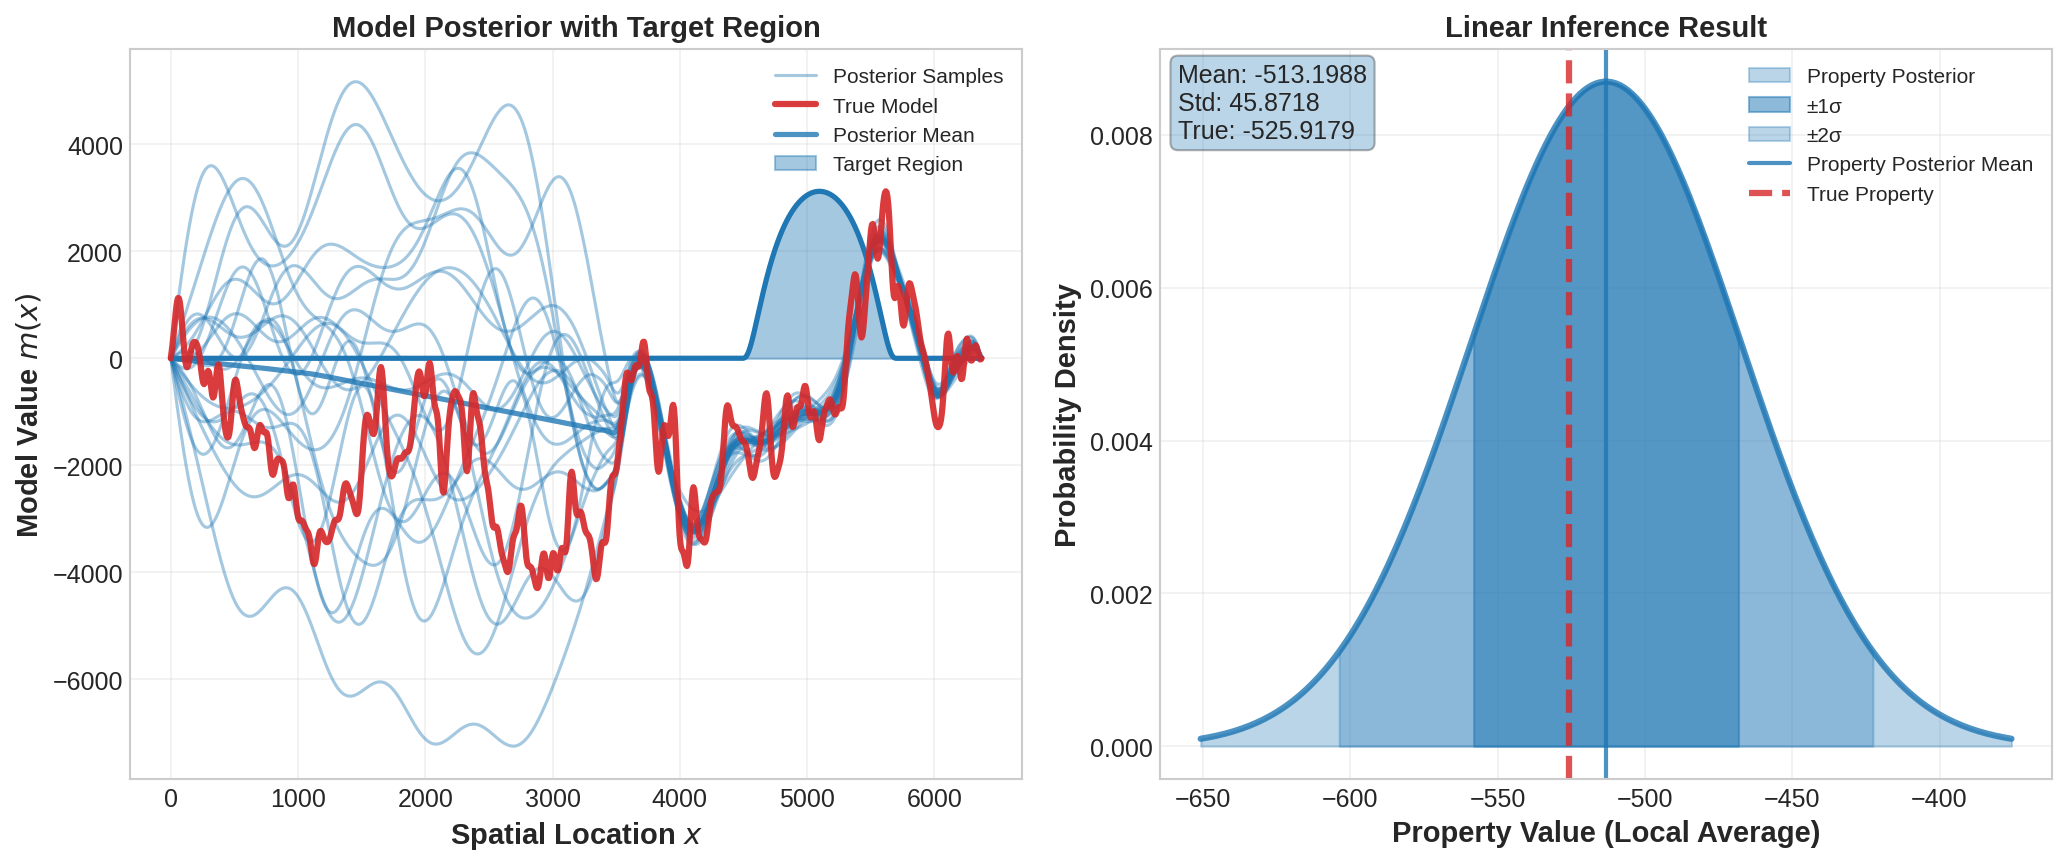

✅ Slide 6 figure saved: Linear inference computation and results


In [12]:
# Visualize Linear Inference Results
print("🎨 Creating visualization of linear inference results...")

# Create visualization of inference results
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

# Left panel: Model posterior with target region
ax = axes[0]
# Show some posterior samples (approximation for visualization)
np.random.seed(RANDOM_SEED)
for i in range(n_post_samples):
    sample_values = mu_M.sample().evaluate(x_viz)
    ax.plot(x_viz, sample_values, color='tab:blue', alpha=sample_alpha, linewidth=1.5,
             label='Posterior Samples' if i == 0 else "")

ax.plot(x_viz, m_true.evaluate(x_viz), '-', color='tab:red', linewidth=3, label='True Model', alpha=0.9, zorder=10)
ax.plot(x_viz, posterior_mean.evaluate(x_viz), color='tab:blue', linewidth=2.5, label='Posterior Mean', alpha=0.8, zorder=9)

# Highlight target region
target = (T.adjoint)(P.basis_vector(0))
target_values = target.evaluate(x_viz)
# support is a list of (a, b) tuples in the new API
if target.support is None:
    support_lo, support_hi = DOMAIN.a, DOMAIN.b
else:
    support_lo, support_hi = target.support[0]

ax.fill_between(x_viz, target_values / np.max(target_values) * np.max(m_true.evaluate(x_viz)),
                where=((x_viz >= support_lo) & (x_viz <= support_hi)),
                alpha=0.4, color='tab:blue', label='Target Region')
ax.plot(x_viz, target_values / np.max(target_values) * np.max(m_true.evaluate(x_viz)), color='tab:blue', linewidth=2.5)

ax.set_xlabel('Spatial Location $x$', fontweight='bold')
ax.set_ylabel('Model Value $m(x)$', fontweight='bold')
ax.set_title('Model Posterior with Target Region', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right panel: Property posterior as Gaussian
ax = axes[1]
# Create a nicer Gaussian visualization using the exact posterior from PyGeoInf
x_fine = np.linspace(property_mean[0] - 3*property_std[0], property_mean[0] + 3*property_std[0], 200)
y_fine = (1/(property_std[0] * np.sqrt(2*np.pi))) * np.exp(-0.5*((x_fine - property_mean[0])/property_std[0])**2)

ax.fill_between(x_fine, y_fine, alpha=0.3, color='tab:blue', label='Property Posterior')
ax.plot(x_fine, y_fine, '-', color='tab:blue', linewidth=3, alpha=0.8)

# Add confidence intervals
ax.fill_between(x_fine, y_fine,
                where=((x_fine >= property_mean - property_std) & (x_fine <= property_mean + property_std)),
                alpha=0.5, color='tab:blue', label='±1σ')
ax.fill_between(x_fine, y_fine,
                where=((x_fine >= property_mean - 2*property_std) & (x_fine <= property_mean + 2*property_std)),
                alpha=0.3, color='tab:blue', label='±2σ')

# Mark key values
ax.axvline(property_mean, color='tab:blue', linestyle='-', linewidth=2, alpha=0.8, label='Property Posterior Mean')
ax.axvline(true_property[0], color='tab:red', linestyle='--', linewidth=3, alpha=0.8, label='True Property')

ax.set_xlabel('Property Value (Local Average)', fontweight='bold')
ax.set_ylabel('Probability Density', fontweight='bold')
ax.set_title('Linear Inference Result', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Add text summary
textstr = f'Mean: {property_mean[0]:.4f}\nStd: {property_std[0]:.4f}\nTrue: {true_property[0]:.4f}'
props = dict(boxstyle='round', facecolor='tab:blue', alpha=0.3)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig(f'{presentation_dir}/slide6_linear_inference_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Slide 6 figure saved: Linear inference computation and results")

In [13]:
X = T @ G.adjoint @ solver(G @ G.adjoint + gaussian_D.covariance)
A = X @ G

In [14]:
gaussian_p_sola = gaussian_D.affine_mapping(operator=X)


In [15]:
property_mean_sola = gaussian_p_sola.expectation
property_cov_sola = gaussian_p_sola.covariance.matrix(dense=True)
property_std_sola = np.sqrt(np.diag(property_cov_sola))

🎨 Creating visualization of linear inference results...


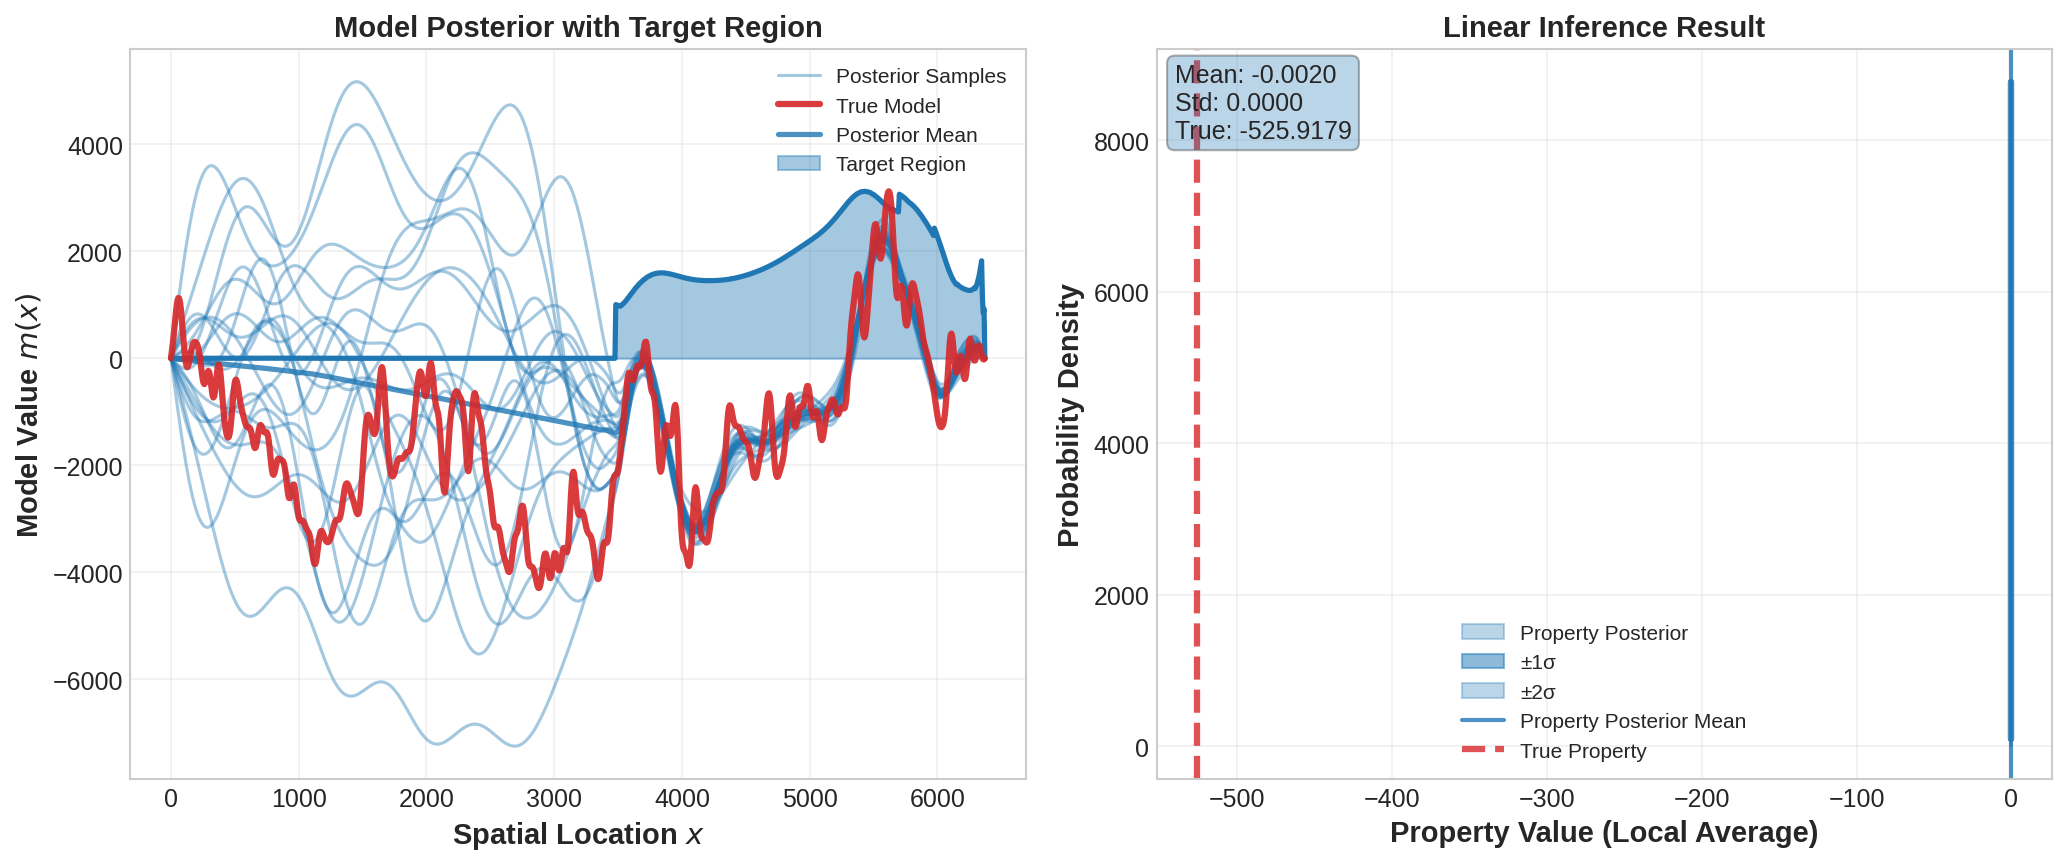

✅ Slide 6 figure saved: Linear inference computation and results


In [16]:
# Visualize Linear Inference Results
print("🎨 Creating visualization of linear inference results...")

# Create visualization of inference results
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

# Left panel: Model posterior with target region
ax = axes[0]
# Show some posterior samples (approximation for visualization)
np.random.seed(RANDOM_SEED)
for i in range(n_post_samples):
    sample_values = mu_M.sample().evaluate(x_viz)
    ax.plot(x_viz, sample_values, color='tab:blue', alpha=sample_alpha, linewidth=1.5,
             label='Posterior Samples' if i == 0 else "")

ax.plot(x_viz, m_true.evaluate(x_viz), '-', color='tab:red', linewidth=3, label='True Model', alpha=0.9, zorder=10)
ax.plot(x_viz, posterior_mean.evaluate(x_viz), color='tab:blue', linewidth=2.5, label='Posterior Mean', alpha=0.8, zorder=9)

# Highlight target region
target = (A.adjoint)(P.basis_vector(0))
target_values = target.evaluate(x_viz)
# support is a list of (a, b) tuples in the new API
if target.support is None:
    support_lo, support_hi = DOMAIN.a, DOMAIN.b
else:
    support_lo, support_hi = target.support[0]

ax.fill_between(x_viz, target_values / np.max(target_values) * np.max(m_true.evaluate(x_viz)),
                where=((x_viz >= support_lo) & (x_viz <= support_hi)),
                alpha=0.4, color='tab:blue', label='Target Region')
ax.plot(x_viz, target_values / np.max(target_values) * np.max(m_true.evaluate(x_viz)), color='tab:blue', linewidth=2.5)

ax.set_xlabel('Spatial Location $x$', fontweight='bold')
ax.set_ylabel('Model Value $m(x)$', fontweight='bold')
ax.set_title('Model Posterior with Target Region', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right panel: Property posterior as Gaussian
ax = axes[1]
# Create a nicer Gaussian visualization using the exact posterior from PyGeoInf
x_fine = np.linspace(property_mean_sola[0] - 3*property_std_sola[0], property_mean_sola[0] + 3*property_std_sola[0], 200)
y_fine = (1/(property_std_sola[0] * np.sqrt(2*np.pi))) * np.exp(-0.5*((x_fine - property_mean_sola[0])/property_std_sola[0])**2)

ax.fill_between(x_fine, y_fine, alpha=0.3, color='tab:blue', label='Property Posterior')
ax.plot(x_fine, y_fine, '-', color='tab:blue', linewidth=3, alpha=0.8)

# Add confidence intervals
ax.fill_between(x_fine, y_fine,
                where=((x_fine >= property_mean_sola - property_std_sola) & (x_fine <= property_mean_sola + property_std_sola)),
                alpha=0.5, color='tab:blue', label='±1σ')
ax.fill_between(x_fine, y_fine,
                where=((x_fine >= property_mean_sola - 2*property_std_sola) & (x_fine <= property_mean_sola + 2*property_std_sola)),
                alpha=0.3, color='tab:blue', label='±2σ')

# Mark key values
ax.axvline(property_mean_sola, color='tab:blue', linestyle='-', linewidth=2, alpha=0.8, label='Property Posterior Mean')
ax.axvline(true_property[0], color='tab:red', linestyle='--', linewidth=3, alpha=0.8, label='True Property')

ax.set_xlabel('Property Value (Local Average)', fontweight='bold')
ax.set_ylabel('Probability Density', fontweight='bold')
ax.set_title('Linear Inference Result', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Add text summary
textstr = f'Mean: {property_mean_sola[0]:.4f}\nStd: {property_std_sola[0]:.4f}\nTrue: {true_property[0]:.4f}'
props = dict(boxstyle='round', facecolor='tab:blue', alpha=0.3)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig(f'{presentation_dir}/slide6_linear_inference_results_sola.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Slide 6 figure saved: Linear inference computation and results")

## Multi-k Bump Function Analysis

In this section, we investigate how the shape parameter $k$ in the bump function affects both:
1. **Target kernel shape**: The spatial structure of our target operator
2. **Linear inference results**: The property posterior distribution

We'll analyze $k$ values from 0 to 10, where:
- $k = 0$: Box-like function (sharp boundaries)  
- $k \to \infty$: Gaussian-like function (smooth boundaries)

The generalized bump function is given by:
$$\phi_k(t) = \frac{1}{Z_k} \exp\left(\frac{k \cdot t}{t^2 - 1}\right) \quad \text{for } t \in (-1, 1)$$

where $Z_k$ is the normalization constant ensuring $\int_{-1}^{1} \phi_k(t) \, dt = 1$.

In [17]:
if False:
    # Simplified Multi-k Bump Function Analysis
    print("🔬 Starting Simplified Multi-k Bump Function Analysis...")

    # Define k values to analyze
    k_values = np.concatenate(([0.0], np.logspace(-3, 1, 59)))
    print(f"📊 Analyzing k values: {k_values}")

    # Setup for single target location analysis
    P_single = EuclideanSpace(1)  # Single property
    center_single = 0.8 * DOMAIN.length  # Single target location
    desired_width_single = 0.15 * DOMAIN.length
    alpha = 0.5
    print(f"🎯 Target location: {center_single}")
    print(f"📏 Target width: {desired_width_single}")

    # Storage for simplified results
    results_simple = {
        'k_values': k_values,
        'property_means': [],
        'property_stds': [],
        'target_kernels': [],
        'true_values': [],
        'computation_success': []
    }

    import concurrent.futures

    def analyze_k(k):
        try:
            from intervalinf.providers import BumpFunctionProvider
            from intervalinf.operators import SOLAOperator
            from intervalinf.core.config import IntegrationConfig
            import numpy as np

            width_single = desired_width_single * (np.sqrt( (np.log(alpha) - k) / np.log(alpha) ))

            target_provider_k = BumpFunctionProvider(
                M,
                centers=np.array([center_single]),
                default_width=width_single,
                default_k=k
            )
            T_k = SOLAOperator(M, P_single, kernels=target_provider_k,
                               integration_config=IntegrationConfig(method='trapz', n_points=1000))
            # Use push-forward of model posterior instead of LinearBayesianInference
            property_posterior_k = model_posterior.affine_mapping(operator=T_k)
            prop_mean = property_posterior_k.expectation[0]
            prop_cov = property_posterior_k.covariance.matrix(dense=True)
            prop_std = np.sqrt(prop_cov[0, 0])
            true_prop = T_k(m_true)[0]
            target_kernel = target_provider_k.get_function_by_index(0).evaluate(x_viz)
            return (prop_mean, prop_std, target_kernel, true_prop, True, None)
        except Exception as e:
            return (0.0, 0.0, np.zeros_like(x_viz), 0.0, False, str(e))

    print("🔬 Starting Parallel Multi-k Bump Function Analysis...")

    with concurrent.futures.ProcessPoolExecutor() as executor:
        results = list(executor.map(analyze_k, k_values))

    results_simple = {
        'k_values': k_values,
        'property_means': [],
        'property_stds': [],
        'target_kernels': [],
        'true_values': [],
        'computation_success': []
    }
    for i, (prop_mean, prop_std, target_kernel, true_prop, success, err) in enumerate(results):
        if success:
            print(f"   ✓ Success - Mean: {prop_mean:.4f}, Std: {prop_std:.4f}, True: {true_prop:.4f}")
        else:
            print(f"   ❌ Failed for k={k_values[i]} - Error: {err}")
        results_simple['property_means'].append(prop_mean)
        results_simple['property_stds'].append(prop_std)
        results_simple['target_kernels'].append(target_kernel)
        results_simple['true_values'].append(true_prop)
        results_simple['computation_success'].append(success)

    print(f"\n✅ Parallel multi-k analysis completed")
    print(f"📊 Successful computations: {sum(results_simple['computation_success'])}/{len(k_values)}")

In [18]:
# Create video from k analysis frames
print("🎬 Creating video from k analysis frames...")
if False:
    try:
        import imageio.v2 as imageio
        import matplotlib.animation as animation
        from matplotlib.patches import Rectangle
        import glob

        # Create frames directory for organized output
        frames_dir = os.path.join(presentation_dir, 'k_animation_frames')
        os.makedirs(frames_dir, exist_ok=True)

        # Generate individual frames for the video
        print("📸 Generating individual frames...")

        # Precompute fixed axis limits so they don't change between frames.
        # Left panel (model posterior) - use x_viz range and min/max of model and posterior mean
        try:
            m_true_vals = m_true.evaluate(x_viz)
        except Exception:
            m_true_vals = np.array(m_true.evaluate(x_viz)) if hasattr(m_true, 'evaluate') else np.zeros_like(x_viz)
        try:
            posterior_mean_vals = posterior_mean.evaluate(x_viz)
        except Exception:
            posterior_mean_vals = np.array(posterior_mean.evaluate(x_viz)) if hasattr(posterior_mean, 'evaluate') else np.zeros_like(x_viz)

        x_min, x_max = np.min(x_viz), np.max(x_viz)
        global_ymin = float(np.min(np.concatenate([np.ravel(m_true_vals), np.ravel(posterior_mean_vals)])))
        global_ymax = float(np.max(np.concatenate([np.ravel(m_true_vals), np.ravel(posterior_mean_vals)])))
        # Add a small vertical padding
        if global_ymax > global_ymin:
            left_pad = 0.05 * (global_ymax - global_ymin)
        else:
            left_pad = 1.0
        left_xlim = (x_min, x_max)
        left_ylim = (global_ymin - left_pad, global_ymax + left_pad)

        # Right panel (property posterior) - compute global x/y ranges across successful results
        prop_means = results_simple.get('property_means', [])
        prop_stds = results_simple.get('property_stds', [])
        prop_x_min = np.inf
        prop_x_max = -np.inf
        prop_y_max = 0.0
        for success, pm, ps in zip(results_simple.get('computation_success', []), prop_means, prop_stds):
            if not success:
                continue
            try:
                if ps is None or ps <= 0 or np.isnan(ps):
                    continue
            except Exception:
                continue
            xmin = pm - 3*ps
            xmax = pm + 3*ps
            prop_x_min = min(prop_x_min, xmin)
            prop_x_max = max(prop_x_max, xmax)
            # peak of Gaussian pdf
            ypeak = 1.0/(ps * np.sqrt(2*np.pi))
            prop_y_max = max(prop_y_max, ypeak)
        if prop_x_min == np.inf or prop_x_max == -np.inf:
            # fallback defaults
            prop_x_min, prop_x_max = -1.0, 1.0
        if prop_y_max <= 0:
            prop_y_max = 1.0
        prop_pad_x = 0.05*(prop_x_max - prop_x_min) if prop_x_max > prop_x_min else 0.5
        prop_pad_y = 0.05*prop_y_max
        right_xlim = (prop_x_min - prop_pad_x, prop_x_max + prop_pad_x)
        right_ylim = (0.0, prop_y_max + prop_pad_y)

        for i, k in enumerate(k_values):
            if not results_simple['computation_success'][i]:
                continue

            # Create figure with same style as linear inference visualization
            fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

            # Left panel: Model posterior with target region (like the original visualization)
            ax = axes[0]
            # Show some posterior samples (approximation for visualization)
            np.random.seed(RANDOM_SEED)
            for j in range(n_post_samples):
                sample_values = mu_M.sample().evaluate(x_viz)
                ax.plot(x_viz, sample_values, color='tab:blue', alpha=sample_alpha, linewidth=1.5,
                        label='Posterior Samples' if j == 0 else "")

            ax.plot(x_viz, m_true.evaluate(x_viz), '-', color='tab:red', linewidth=3, label='True Model', alpha=0.9, zorder=10)
            ax.plot(x_viz, posterior_mean.evaluate(x_viz), color='tab:blue', linewidth=2.5, label='Posterior Mean', alpha=0.8, zorder=9)

            # Get current target kernel for this k value
            target_kernel = results_simple['target_kernels'][i]

            # Create a temporary target kernel provider for this k to get the region bounds
            try:
                # Estimate width from current target kernel (find where it's > 1% of max)
                # compute y exactly as in your plot
                y = np.max(m_true.evaluate(x_viz)) * target_kernel / np.max(target_kernel)

                # plot the line (your existing line)
                ax.plot(x_viz, y, color='tab:blue', linewidth=4, label='Target Kernel $T(x)$', alpha=0.6, zorder=3)

                # fill between the curve and the x-axis (y=0), only where the curve is above the axis
                baseline = 0.0
                ax.fill_between(x_viz,
                                baseline,
                                y,
                                where=(y > baseline),           # only fill where curve is above x-axis
                                interpolate=True,
                                color='tab:blue',
                                alpha=0.25,
                                zorder=2)
            except Exception:
                pass  # Skip region highlighting if there's an issue

            ax.set_xlabel('Spatial Location $x$', fontweight='bold')
            ax.set_ylabel('Model Value $m(x)$', fontweight='bold')
            ax.set_title(f'Model Posterior with Target Region (k={k:.3f})', fontsize=14, fontweight='bold')
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)

            # Apply fixed limits for left panel
            ax.set_xlim(left_xlim)
            ax.set_ylim(left_ylim)

            # Right panel: Property posterior as Gaussian (exactly like the original)
            ax = axes[1]
            prop_mean = results_simple['property_means'][i]
            prop_std = results_simple['property_stds'][i]
            true_prop = results_simple['true_values'][i]

            # Create a nicer Gaussian visualization using the exact posterior style
            x_fine = np.linspace(prop_mean - 3*prop_std, prop_mean + 3*prop_std, 200)
            y_fine = (1/(prop_std * np.sqrt(2*np.pi))) * np.exp(-0.5*((x_fine - prop_mean)/prop_std)**2)

            ax.fill_between(x_fine, y_fine, alpha=0.3, color='tab:blue', label='Property Posterior')
            ax.plot(x_fine, y_fine, '-', color='tab:blue', linewidth=3, alpha=0.8)

            # Add confidence intervals
            ax.fill_between(x_fine, y_fine,
                            where=((x_fine >= prop_mean - prop_std) & (x_fine <= prop_mean + prop_std)),
                            alpha=0.5, color='tab:blue', label='±1σ')
            ax.fill_between(x_fine, y_fine,
                            where=((x_fine >= prop_mean - 2*prop_std) & (x_fine <= prop_mean + 2*prop_std)),
                            alpha=0.3, color='tab:blue', label='±2σ')

            # Mark key values
            ax.axvline(prop_mean, color='tab:blue', linestyle='-', linewidth=2, alpha=0.8, label='Property Posterior Mean')
            ax.axvline(true_prop, color='tab:red', linestyle='--', linewidth=3, alpha=0.8, label='True Property')

            ax.set_xlabel('Property Value (Local Average)', fontweight='bold')
            ax.set_ylabel('Probability Density', fontweight='bold')
            ax.set_title(f'Linear Inference Result (k={k:.3f})', fontsize=14, fontweight='bold')
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)

            # Apply fixed limits for right panel
            ax.set_xlim(right_xlim)
            ax.set_ylim(right_ylim)

            # Add text summary (like the original)
            error_sigma = abs(prop_mean - true_prop)/prop_std if prop_std > 0 else 0
            textstr = f'k: {k:.4f}\nMean: {prop_mean:.4f}\nStd: {prop_std:.4f}\nTrue: {true_prop:.4f}\nError: {abs(prop_mean - true_prop):.4f}\nError (σ): {error_sigma:.2f}'
            props = dict(boxstyle='round', facecolor='tab:blue', alpha=0.3)
            ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=12,
                    verticalalignment='top', bbox=props)

            plt.tight_layout()

            # Save frame
            frame_filename = os.path.join(frames_dir, f'frame_{i:02d}_k_{k:.4f}.png')
            fig.savefig(frame_filename, dpi=300, bbox_inches='tight', facecolor='white')
            plt.close(fig)

            if i % 3 == 0:  # Progress update every few frames
                print(f"   Frame {i+1}/{len(k_values)} completed")

        print(f"📁 Frames saved in: {frames_dir}")

        # Create video from frames
        print("🎥 Creating video from frames...")

        # Get list of frame files in order
        frame_files = []
        for i, k in enumerate(k_values):
            if results_simple['computation_success'][i]:
                frame_file = os.path.join(frames_dir, f'frame_{i:02d}_k_{k:.4f}.png')
                if os.path.exists(frame_file):
                    frame_files.append(frame_file)

        if len(frame_files) > 0:
            # Create video using imageio
            video_filename = os.path.join(presentation_dir, 'k_analysis_animation.mp4')

            with imageio.get_writer(video_filename, mode='I', fps=2, macro_block_size=None) as writer:
                for frame_file in frame_files:
                    image = imageio.imread(frame_file)
                    writer.append_data(image)
                    # Hold last frame longer
                    if frame_file == frame_files[-1]:
                        for _ in range(4):  # Hold for 2 extra seconds at 2 fps
                            writer.append_data(image)

            print(f"✅ Video created: {video_filename}")
            print(f"🎬 Video duration: ~{len(frame_files)/2 + 2:.1f} seconds")
            print(f"📊 Video shows evolution of bump function analysis across k values")

            # Optional: create GIF version
            gif_filename = os.path.join(presentation_dir, 'k_analysis_animation.gif')
            with imageio.get_writer(gif_filename, mode='I', duration=0.5, loop=0) as writer:
                for frame_file in frame_files:
                    image = imageio.imread(frame_file)
                    writer.append_data(image)
                    # Hold last frame
                    if frame_file == frame_files[-1]:
                        for _ in range(3):
                            writer.append_data(image)

            print(f"✅ GIF created: {gif_filename}")

        else:
            print("❌ No frame files found - cannot create video")

    except ImportError as e:
        print(f"❌ Missing required packages for video creation: {e}")
        print("💡 Install with: pip install imageio[ffmpeg]")
    except Exception as e:
        print(f"❌ Error creating video: {e}")

    print("🎯 Multi-k analysis and video generation completed!")

🎬 Creating video from k analysis frames...
